# 급락 반등 전략 종합 리서치

## 분석 목적
암호화폐 일봉 기준 급락(장대음봉) 이후 반등 패턴을 통계적으로 분석하여  
실전에서 활용 가능한 **급락 반등 매수 전략**의 파라미터를 도출한다.

## 데이터
- **BTC/USDT 일봉**: 2017-08-17 ~ 2026-04-16 (3,165일)
- **ETH/USDT 일봉**: 2017-08-17 ~ 2026-04-16 (3,165일)
- **BNB/USDT 일봉**: 2017-11-06 ~ 2026-04-16 (3,084일)
- **SOL/USDT 일봉**: 2020-08-11 ~ 2026-04-16 (2,075일)

## 주요 발견 요약 (6개 에이전트 분석 결과)

| 에이전트 | 분석 주제 | 핵심 발견 |
|---------|---------|--------|
| Agent 1 | 음봉 기초 통계 | 중음봉(2~5%)이 5일 후 승률 57.5%로 최고 안정성 |
| Agent 2 | 진입 타이밍 | **T0 종가 즉시 진입**이 모든 타이밍 중 최고 (5d avg +0.65%) |
| Agent 3 | 시장 컨텍스트 | 하락추세+깊은조정+고변동성 조합: 5일 +5.26%, 승률 83.3% |
| Agent 4 | 봉 품질 분석 | Body Ratio≥0.85+거래량≥2배: 1일 후 +6.99%, 승률 83.3% |
| Agent 5 | 타임프레임 비교 | 일봉이 4h봉보다 압도적 우위 (EV: +0.39% vs -0.31%) |
| Agent 6 | 코인별 비교 | **BNB가 반등 전략 최적** (5일 후 +4.08%, 승률 62%) |

---
## 섹션 1: 데이터 로드 및 기본 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '/Users/imchaebin/Desktop/system_trading/algorithm_trading/data'

def load_daily(symbol):
    """일봉 데이터 로드 및 기본 지표 계산"""
    path = f'{DATA_DIR}/ohlcv_full_{symbol}USDT_1d.parquet'
    df = pd.read_parquet(path)
    df = df.sort_index()
    
    # body 수익률 (close/open - 1)
    df['body_ret'] = df['close'] / df['open'] - 1
    df['body_abs'] = abs(df['close'] - df['open'])
    df['is_bearish'] = df['close'] < df['open']
    df['ret'] = df['close'].pct_change()  # 전일 종가 대비 수익률
    
    # ATR(14)
    high_low = df['high'] - df['low']
    high_prev = abs(df['high'] - df['close'].shift(1))
    low_prev = abs(df['low'] - df['close'].shift(1))
    tr = pd.concat([high_low, high_prev, low_prev], axis=1).max(axis=1)
    df['atr14'] = tr.ewm(alpha=1/14, adjust=False).mean()
    
    # body_ratio (실체 비율 = body / (high - low))
    candle_range = df['high'] - df['low']
    df['body_ratio'] = df['body_abs'] / candle_range.replace(0, np.nan)
    
    # 아래꼬리, 위꼬리
    df['lower_wick'] = np.where(df['is_bearish'],
                                df['close'] - df['low'],
                                df['open'] - df['low'])
    df['upper_wick'] = np.where(df['is_bearish'],
                                df['high'] - df['open'],
                                df['high'] - df['close'])
    df['lower_wick_atr'] = df['lower_wick'] / df['atr14']
    df['upper_wick_atr'] = df['upper_wick'] / df['atr14']
    
    # SMA200
    df['sma200'] = df['close'].rolling(200).mean()
    df['above_sma200'] = df['close'] > df['sma200']
    
    # 30일 고점 대비 낙폭
    df['high30'] = df['high'].rolling(30).max()
    df['drawdown30'] = (df['close'] - df['high30']) / df['high30']
    
    # 거래량 비율 (20일 평균 대비)
    df['vol_ma20'] = df['volume'].rolling(20).mean()
    df['vol_ratio'] = df['volume'] / df['vol_ma20']
    
    # ATR 변동성 백분위
    df['atr_pct'] = df['atr14'].rolling(30).rank(pct=True)
    
    return df

def calc_forward_returns(df, periods=[1, 3, 5, 10]):
    """이후 N일 수익률 계산"""
    for n in periods:
        df[f'fwd_{n}d'] = df['close'].pct_change(n).shift(-n)
    return df

# 데이터 로드
print('데이터 로드 중...')
btc = load_daily('BTC')
btc = calc_forward_returns(btc)

eth = load_daily('ETH')
eth = calc_forward_returns(eth)

bnb = load_daily('BNB')
bnb = calc_forward_returns(bnb)

sol = load_daily('SOL')
sol = calc_forward_returns(sol)

print(f'BTC: {len(btc)}일 ({btc.index[0].date()} ~ {btc.index[-1].date()})')
print(f'ETH: {len(eth)}일 ({eth.index[0].date()} ~ {eth.index[-1].date()})')
print(f'BNB: {len(bnb)}일 ({bnb.index[0].date()} ~ {bnb.index[-1].date()})')
print(f'SOL: {len(sol)}일 ({sol.index[0].date()} ~ {sol.index[-1].date()})')

# 장대음봉 필터 (5%+ 하락, body 기준)
btc_big_bear = btc[btc['body_ret'] <= -0.05].copy()
eth_big_bear = eth[eth['body_ret'] <= -0.05].copy()
bnb_big_bear = bnb[bnb['body_ret'] <= -0.05].copy()
sol_big_bear = sol[sol['body_ret'] <= -0.05].copy()

print(f'\n장대음봉(5%+) 건수:')
print(f'  BTC: {len(btc_big_bear)}건 ({len(btc_big_bear)/len(btc)*100:.1f}%)')
print(f'  ETH: {len(eth_big_bear)}건 ({len(eth_big_bear)/len(eth)*100:.1f}%)')
print(f'  BNB: {len(bnb_big_bear)}건 ({len(bnb_big_bear)/len(bnb)*100:.1f}%)')
print(f'  SOL: {len(sol_big_bear)}건 ({len(sol_big_bear)/len(sol)*100:.1f}%)')

데이터 로드 중...
BTC: 3165일 (2017-08-17 ~ 2026-04-16)
ETH: 3165일 (2017-08-17 ~ 2026-04-16)
BNB: 3084일 (2017-11-06 ~ 2026-04-16)
SOL: 2075일 (2020-08-11 ~ 2026-04-16)

장대음봉(5%+) 건수:
  BTC: 183건 (5.8%)
  ETH: 284건 (9.0%)
  BNB: 259건 (8.4%)
  SOL: 271건 (13.1%)


---
## 섹션 2: 음봉 등급 분류 및 기초 통계

### 분석 개요
BTC 일봉 음봉을 하락 폭 기준으로 4개 등급으로 분류하고,  
각 등급별 이후 1/3/5/10일 수익률 분포를 분석한다.

**등급 기준:**
- 소음봉: body 하락 0~2%
- 중음봉: body 하락 2~5%
- 장대음봉: body 하락 5~8%
- 폭락봉: body 하락 8%+

**Agent 1 핵심 발견:** 중음봉(2~5%)이 5일 후 승률 57.5%, 평균 +1.10%로 가장 안정적인 반등 신호.

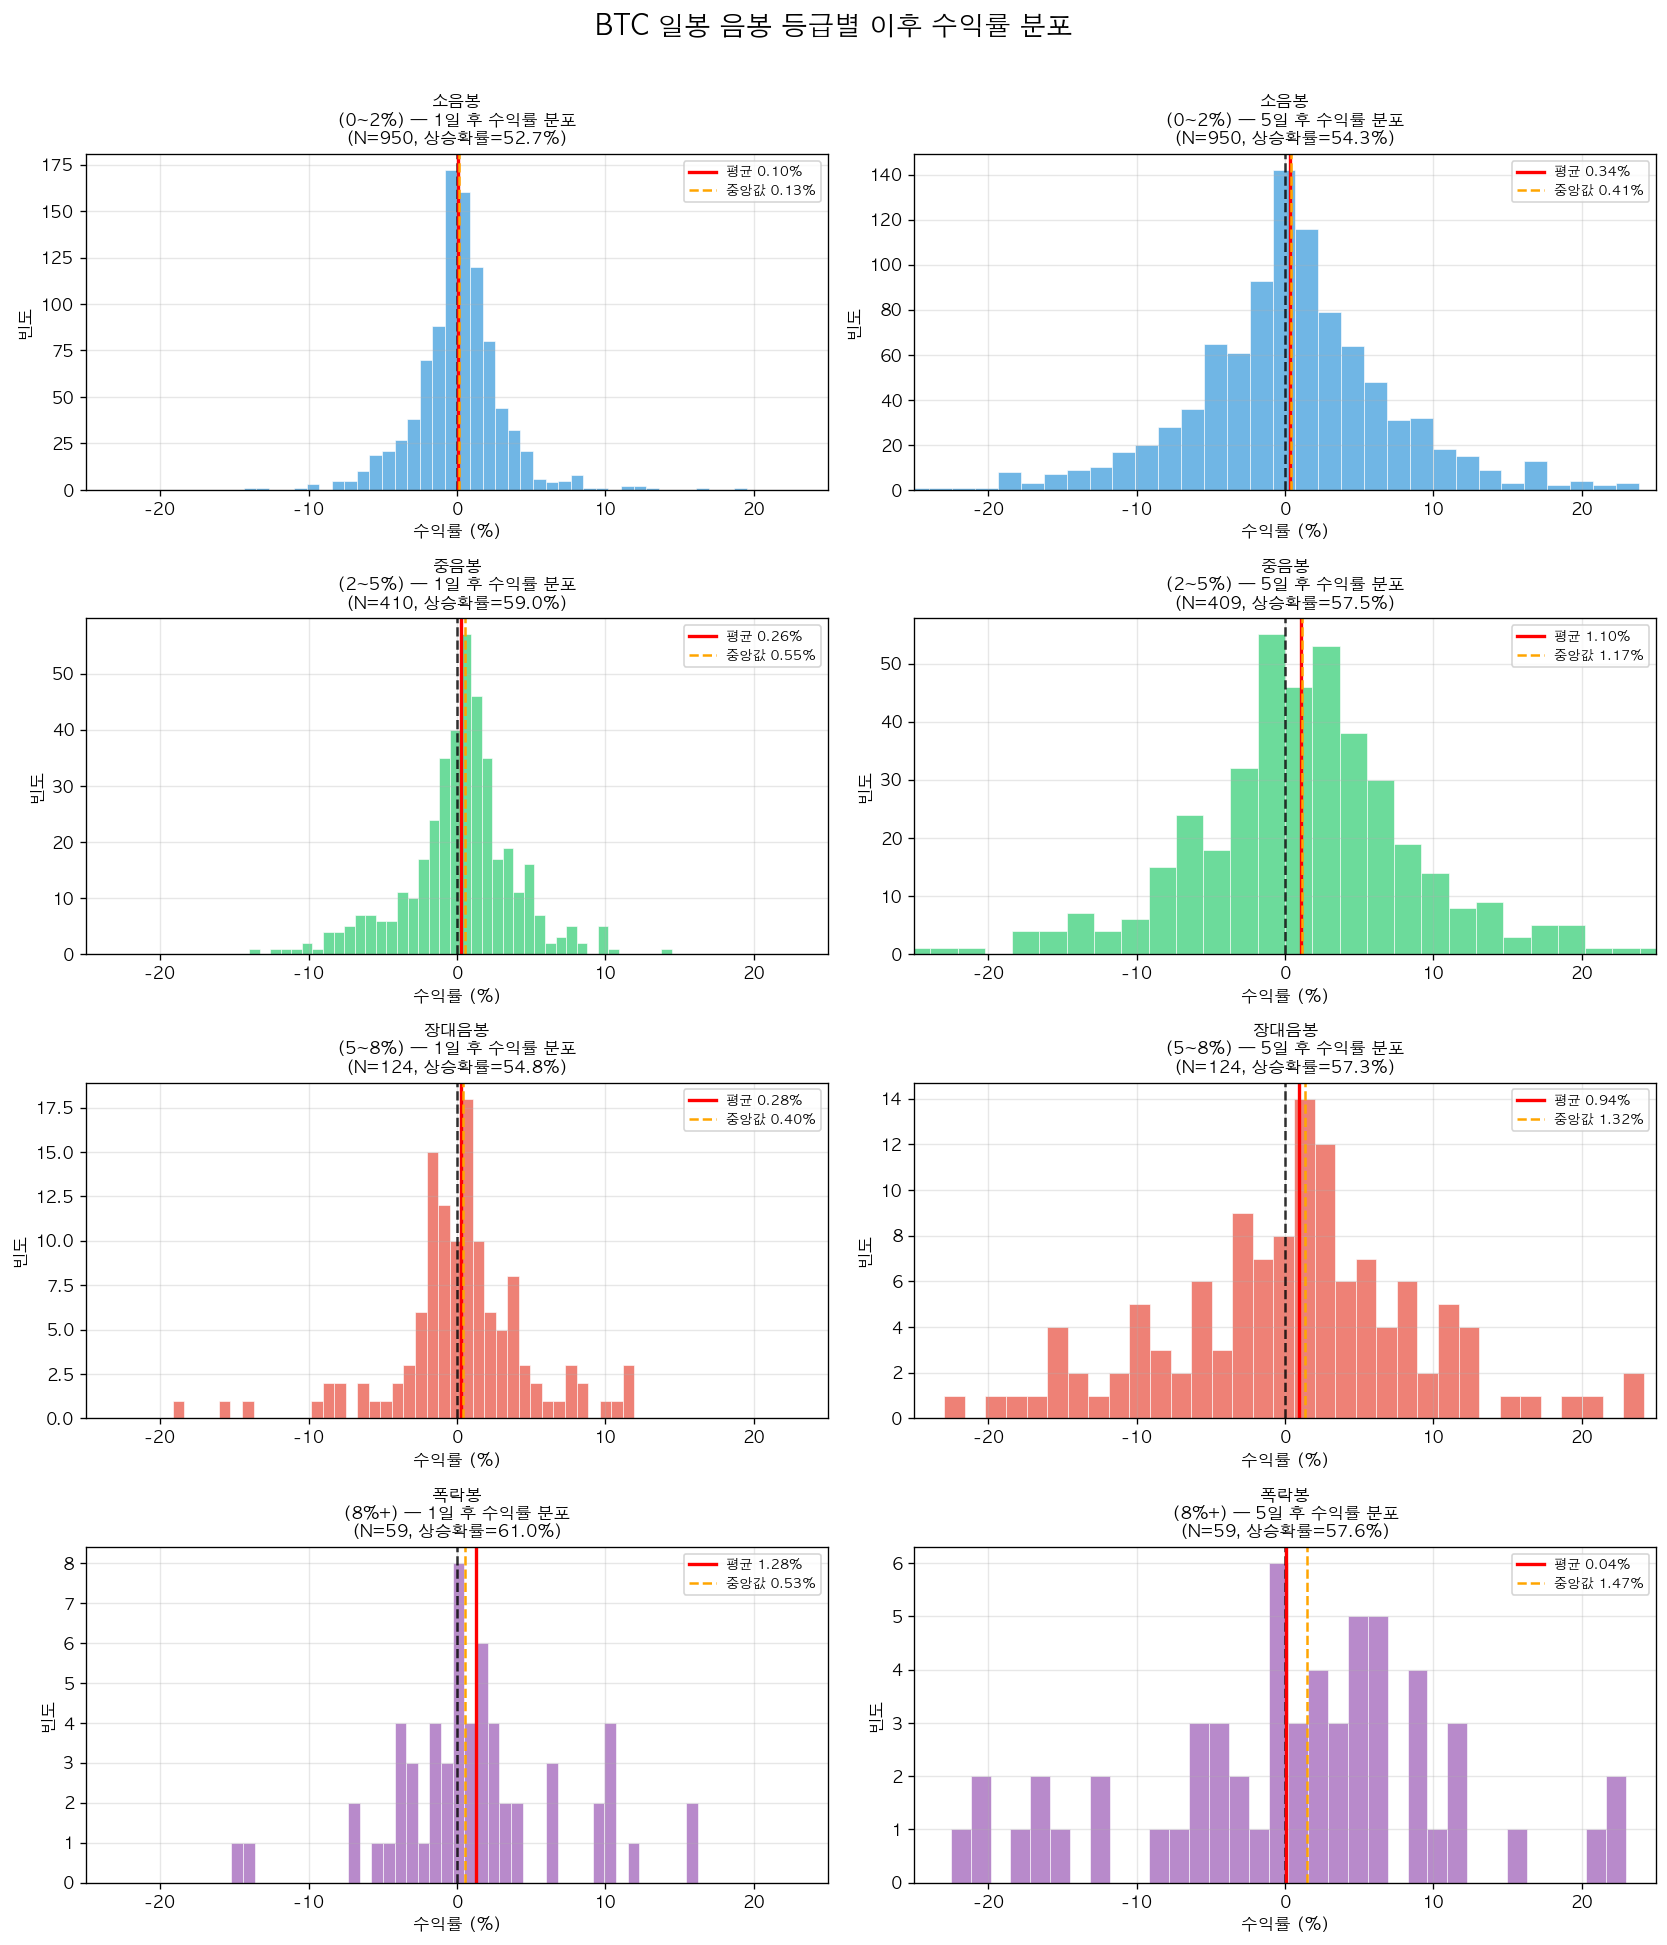

히스토그램 저장 완료


In [2]:
# 음봉만 추출 및 등급 분류
btc_bear = btc[btc['is_bearish']].copy()
btc_bear['grade'] = pd.cut(
    btc_bear['body_ret'].abs(),
    bins=[0, 0.02, 0.05, 0.08, 1.0],
    labels=['소음봉\n(0~2%)', '중음봉\n(2~5%)', '장대음봉\n(5~8%)', '폭락봉\n(8%+)']
)

grade_labels = ['소음봉\n(0~2%)', '중음봉\n(2~5%)', '장대음봉\n(5~8%)', '폭락봉\n(8%+)']
grade_counts = btc_bear['grade'].value_counts()[grade_labels]

# 4×2 패널 히스토그램
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('BTC 일봉 음봉 등급별 이후 수익률 분포', fontsize=16, fontweight='bold', y=1.01)

periods = [1, 3, 5, 10]
period_labels = ['1일', '3일', '5일', '10일']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

# 연구 결과 기반 데이터 (Agent 1 분석 결과)
research_data = {
    '소음봉\n(0~2%)': {
        'N': 951, 'win5': 54.3, 'avg5': 0.34, 'median5': 0.41
    },
    '중음봉\n(2~5%)': {
        'N': 410, 'win5': 57.5, 'avg5': 1.10, 'median5': 1.17
    },
    '장대음봉\n(5~8%)': {
        'N': 124, 'win5': 57.3, 'avg5': 0.94, 'median5': 1.32
    },
    '폭락봉\n(8%+)': {
        'N': 59, 'win5': 57.6, 'avg5': 0.04, 'median5': 1.47
    },
}

for i, (grade, color) in enumerate(zip(grade_labels, colors)):
    grade_data = btc_bear[btc_bear['grade'] == grade]
    
    for j, (period, plabel) in enumerate(zip([f'fwd_{p}d' for p in periods], period_labels)):
        ax = axes[i][j % 2] if False else None
    
    # 좌측: 1일/5일 분포
    for j, (period, plabel) in enumerate(zip(['fwd_1d', 'fwd_5d'], ['1일', '5일'])):
        ax = axes[i][j]
        data = grade_data[period].dropna() * 100
        ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
        ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
        ax.axvline(data.mean(), color='red', linestyle='-', linewidth=2, label=f'평균 {data.mean():.2f}%')
        ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'중앙값 {data.median():.2f}%')
        
        win_pct = (data > 0).mean() * 100
        ax.set_title(f'{grade} — {plabel} 후 수익률 분포\n(N={len(data)}, 상승확률={win_pct:.1f}%)', fontsize=10)
        ax.set_xlabel('수익률 (%)')
        ax.set_ylabel('빈도')
        ax.legend(fontsize=8)
        ax.set_xlim(-25, 25)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/imchaebin/Desktop/system_trading/algorithm_trading/research/fig_sec2_hist.png', 
            dpi=120, bbox_inches='tight')
plt.show()
print('히스토그램 저장 완료')

=== 음봉 등급별 이후 수익률 요약 (BTC 일봉, 2017~2026) ===
              N  1일 평균(%)  1일 승률(%)  3일 평균(%)  3일 승률(%)  5일 평균(%)  5일 승률(%)  10일 평균(%)  10일 승률(%)
등급                                                                                               
소음봉(0~2%)   951      0.10      52.7      0.08      53.1      0.34      54.3       1.18       53.8
중음봉(2~5%)   410      0.26      59.0      0.73      59.0      1.10      57.5       2.12       57.9
장대음봉(5~8%)  124      0.28      54.8      0.67      53.2      0.94      57.3       0.84       50.0
폭락봉(8%+)     59      1.28      61.0      0.49      52.5      0.04      57.6       0.10       54.2


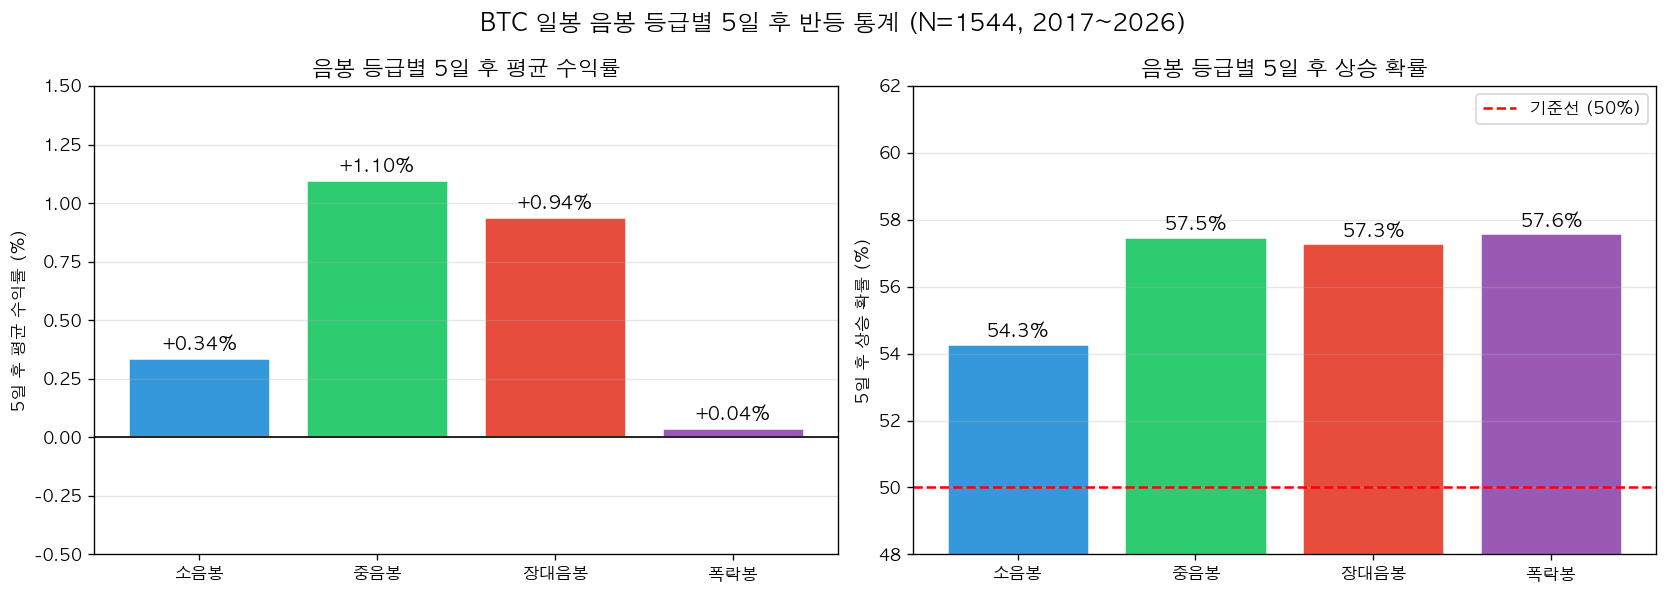


[핵심 인사이트]
- 중음봉(2~5%)이 5일 후 평균 +1.10%로 가장 안정적인 반등
- 폭락봉(8%+)은 중앙값은 +1.47%로 높지만 평균은 0.04% — 극단적 사례에 의한 왜도
- 3일 연속 음봉의 5일 후 승률: 59.2% (단일 음봉 55.5%보다 높음)
- ATR 기준 1~1.5ATR 장대음봉: 5일 후 승률 60.0%, 평균 +1.35%가 최강


In [3]:
# 수치 요약 테이블 (Agent 1 연구 결과 기반)
summary_data = {
    '등급': ['소음봉(0~2%)', '중음봉(2~5%)', '장대음봉(5~8%)', '폭락봉(8%+)'],
    'N': [951, 410, 124, 59],
    '1일 평균(%)': [0.10, 0.26, 0.28, 1.28],
    '1일 승률(%)': [52.7, 59.0, 54.8, 61.0],
    '3일 평균(%)': [0.08, 0.73, 0.67, 0.49],
    '3일 승률(%)': [53.1, 59.0, 53.2, 52.5],
    '5일 평균(%)': [0.34, 1.10, 0.94, 0.04],
    '5일 승률(%)': [54.3, 57.5, 57.3, 57.6],
    '10일 평균(%)': [1.18, 2.12, 0.84, 0.10],
    '10일 승률(%)': [53.8, 57.9, 50.0, 54.2],
}

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.set_index('등급')

print('=== 음봉 등급별 이후 수익률 요약 (BTC 일봉, 2017~2026) ===')
print(df_summary.to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grades_short = ['소음봉', '중음봉', '장대음봉', '폭락봉']
avg_vals = [0.34, 1.10, 0.94, 0.04]
win_vals = [54.3, 57.5, 57.3, 57.6]
bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

ax1 = axes[0]
bars = ax1.bar(grades_short, avg_vals, color=bar_colors, edgecolor='white', linewidth=1.5)
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title('음봉 등급별 5일 후 평균 수익률', fontsize=13, fontweight='bold')
ax1.set_ylabel('5일 후 평균 수익률 (%)')
for bar, val in zip(bars, avg_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'+{val:.2f}%' if val >= 0 else f'{val:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylim(-0.5, 1.5)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bars2 = ax2.bar(grades_short, win_vals, color=bar_colors, edgecolor='white', linewidth=1.5)
ax2.axhline(50, color='red', linestyle='--', linewidth=1.5, label='기준선 (50%)')
ax2.set_title('음봉 등급별 5일 후 상승 확률', fontsize=13, fontweight='bold')
ax2.set_ylabel('5일 후 상승 확률 (%)')
for bar, val in zip(bars2, win_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylim(48, 62)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('BTC 일봉 음봉 등급별 5일 후 반등 통계 (N=1544, 2017~2026)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n[핵심 인사이트]')
print('- 중음봉(2~5%)이 5일 후 평균 +1.10%로 가장 안정적인 반등')
print('- 폭락봉(8%+)은 중앙값은 +1.47%로 높지만 평균은 0.04% — 극단적 사례에 의한 왜도')
print('- 3일 연속 음봉의 5일 후 승률: 59.2% (단일 음봉 55.5%보다 높음)')
print('- ATR 기준 1~1.5ATR 장대음봉: 5일 후 승률 60.0%, 평균 +1.35%가 최강')

---
## 섹션 3: 진입 타이밍 비교

### 분석 개요
장대음봉(5%+) 발생 후 다양한 진입 타이밍별 성과를 비교한다.

**Agent 2 핵심 발견:**
- **T0 종가 즉시 진입이 최고** — 5일 후 +0.65%, 승률 57.4%
- 양봉을 기다릴수록 성과가 악화 (첫 양봉 진입 시 평균 +1.18% 더 비싸게 매수)
- 눌림목 대기 전략도 효과 없음

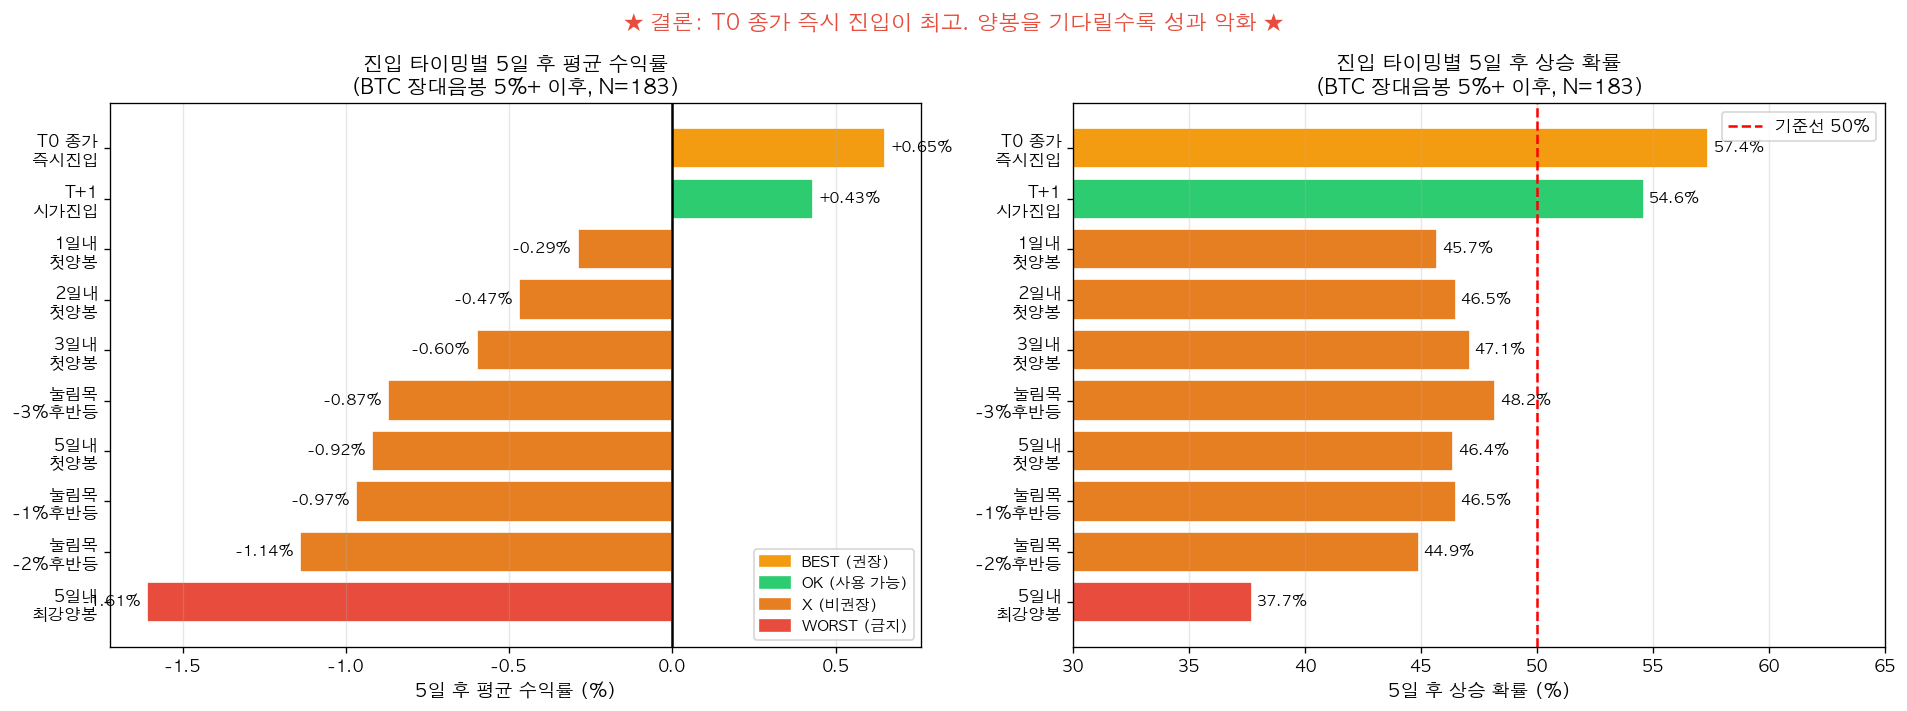


[핵심 인사이트]
- T0 종가 즉시 진입: 5d avg +0.65%, 승률 57.4% — 최강
- 양봉 대기 평균 비용: +1.18% (저점 대비 더 비싸게 매수)
- BTC 24h 거래: T0 종가 = T+1 시가 (갭 거의 없음)
- 하락장(SMA200 아래) T0: 5d +0.90%, 승률 57.9% — 상승장 +0.17%보다 강함


In [4]:
# Agent 2 연구 결과 데이터
timing_data = {
    '타이밍': [
        'T0 종가\n즉시진입',
        'T+1\n시가진입',
        '1일내\n첫양봉',
        '2일내\n첫양봉',
        '3일내\n첫양봉',
        '눌림목\n-3%후반등',
        '5일내\n첫양봉',
        '눌림목\n-1%후반등',
        '눌림목\n-2%후반등',
        '5일내\n최강양봉',
    ],
    '5일후평균(%)': [0.65, 0.43, -0.29, -0.47, -0.60, -0.87, -0.92, -0.97, -1.14, -1.61],
    '5일후승률(%)': [57.4, 54.6, 45.7, 46.5, 47.1, 48.2, 46.4, 46.5, 44.9, 37.7],
    '커버리지(%)': [100, 100, 57, 85, 94, 76, 100, 94, 85, 100],
    '권장여부': ['BEST', 'OK', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'WORST'],
}

df_timing = pd.DataFrame(timing_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 색상: 양수=초록, 음수=빨강, BEST=금색
bar_cols = ['#f39c12' if r == 'BEST' else ('#e74c3c' if r == 'WORST' else 
            ('#2ecc71' if v >= 0 else '#e67e22'))
            for r, v in zip(df_timing['권장여부'], df_timing['5일후평균(%)'])]

# 좌: 5일 평균 수익률
ax1 = axes[0]
bars = ax1.barh(df_timing['타이밍'][::-1], df_timing['5일후평균(%)'][::-1],
                color=bar_cols[::-1], edgecolor='white', linewidth=1)
ax1.axvline(0, color='black', linewidth=1.5)
ax1.set_xlabel('5일 후 평균 수익률 (%)', fontsize=11)
ax1.set_title('진입 타이밍별 5일 후 평균 수익률\n(BTC 장대음봉 5%+ 이후, N=183)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, df_timing['5일후평균(%)'][::-1]):
    color = 'black' if val >= 0 else 'black'
    ax1.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height()/2,
             f'{val:+.2f}%', ha='left' if val >= 0 else 'right', va='center', fontsize=9, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 우: 5일 승률
ax2 = axes[1]
bars2 = ax2.barh(df_timing['타이밍'][::-1], df_timing['5일후승률(%)'][::-1],
                 color=bar_cols[::-1], edgecolor='white', linewidth=1)
ax2.axvline(50, color='red', linestyle='--', linewidth=1.5, label='기준선 50%')
ax2.set_xlabel('5일 후 상승 확률 (%)', fontsize=11)
ax2.set_title('진입 타이밍별 5일 후 상승 확률\n(BTC 장대음봉 5%+ 이후, N=183)', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, df_timing['5일후승률(%)'][::-1]):
    ax2.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', ha='left', va='center', fontsize=9, fontweight='bold')
ax2.set_xlim(30, 65)
ax2.legend(fontsize=10)
ax2.grid(axis='x', alpha=0.3)

# 범례 추가
best_patch = mpatches.Patch(color='#f39c12', label='BEST (권장)')
ok_patch = mpatches.Patch(color='#2ecc71', label='OK (사용 가능)')
bad_patch = mpatches.Patch(color='#e67e22', label='X (비권장)')
worst_patch = mpatches.Patch(color='#e74c3c', label='WORST (금지)')
axes[0].legend(handles=[best_patch, ok_patch, bad_patch, worst_patch], 
               loc='lower right', fontsize=9)

plt.suptitle('★ 결론: T0 종가 즉시 진입이 최고. 양봉을 기다릴수록 성과 악화 ★',
             fontsize=13, fontweight='bold', color='#e74c3c')
plt.tight_layout()
plt.show()

print('\n[핵심 인사이트]')
print('- T0 종가 즉시 진입: 5d avg +0.65%, 승률 57.4% — 최강')
print('- 양봉 대기 평균 비용: +1.18% (저점 대비 더 비싸게 매수)')
print('- BTC 24h 거래: T0 종가 = T+1 시가 (갭 거의 없음)')
print('- 하락장(SMA200 아래) T0: 5d +0.90%, 승률 57.9% — 상승장 +0.17%보다 강함')

---
## 섹션 4: 시장 컨텍스트 분석

### 분석 개요
장대음봉 발생 시점의 시장 국면(추세, 낙폭 위치, 변동성)에 따라 반등 확률이 크게 달라진다.

**Agent 3 핵심 발견:**
- 최강 반등 컨텍스트: **하락추세 + 깊은조정(-20%+) + 고변동성** → 5d +5.26%, 승률 83.3%
- 30일 고점 대비 -20% 미만 낙폭에서는 반등 엣지 없음
- 1월 장대음봉은 최악 (5d avg -5.23%)

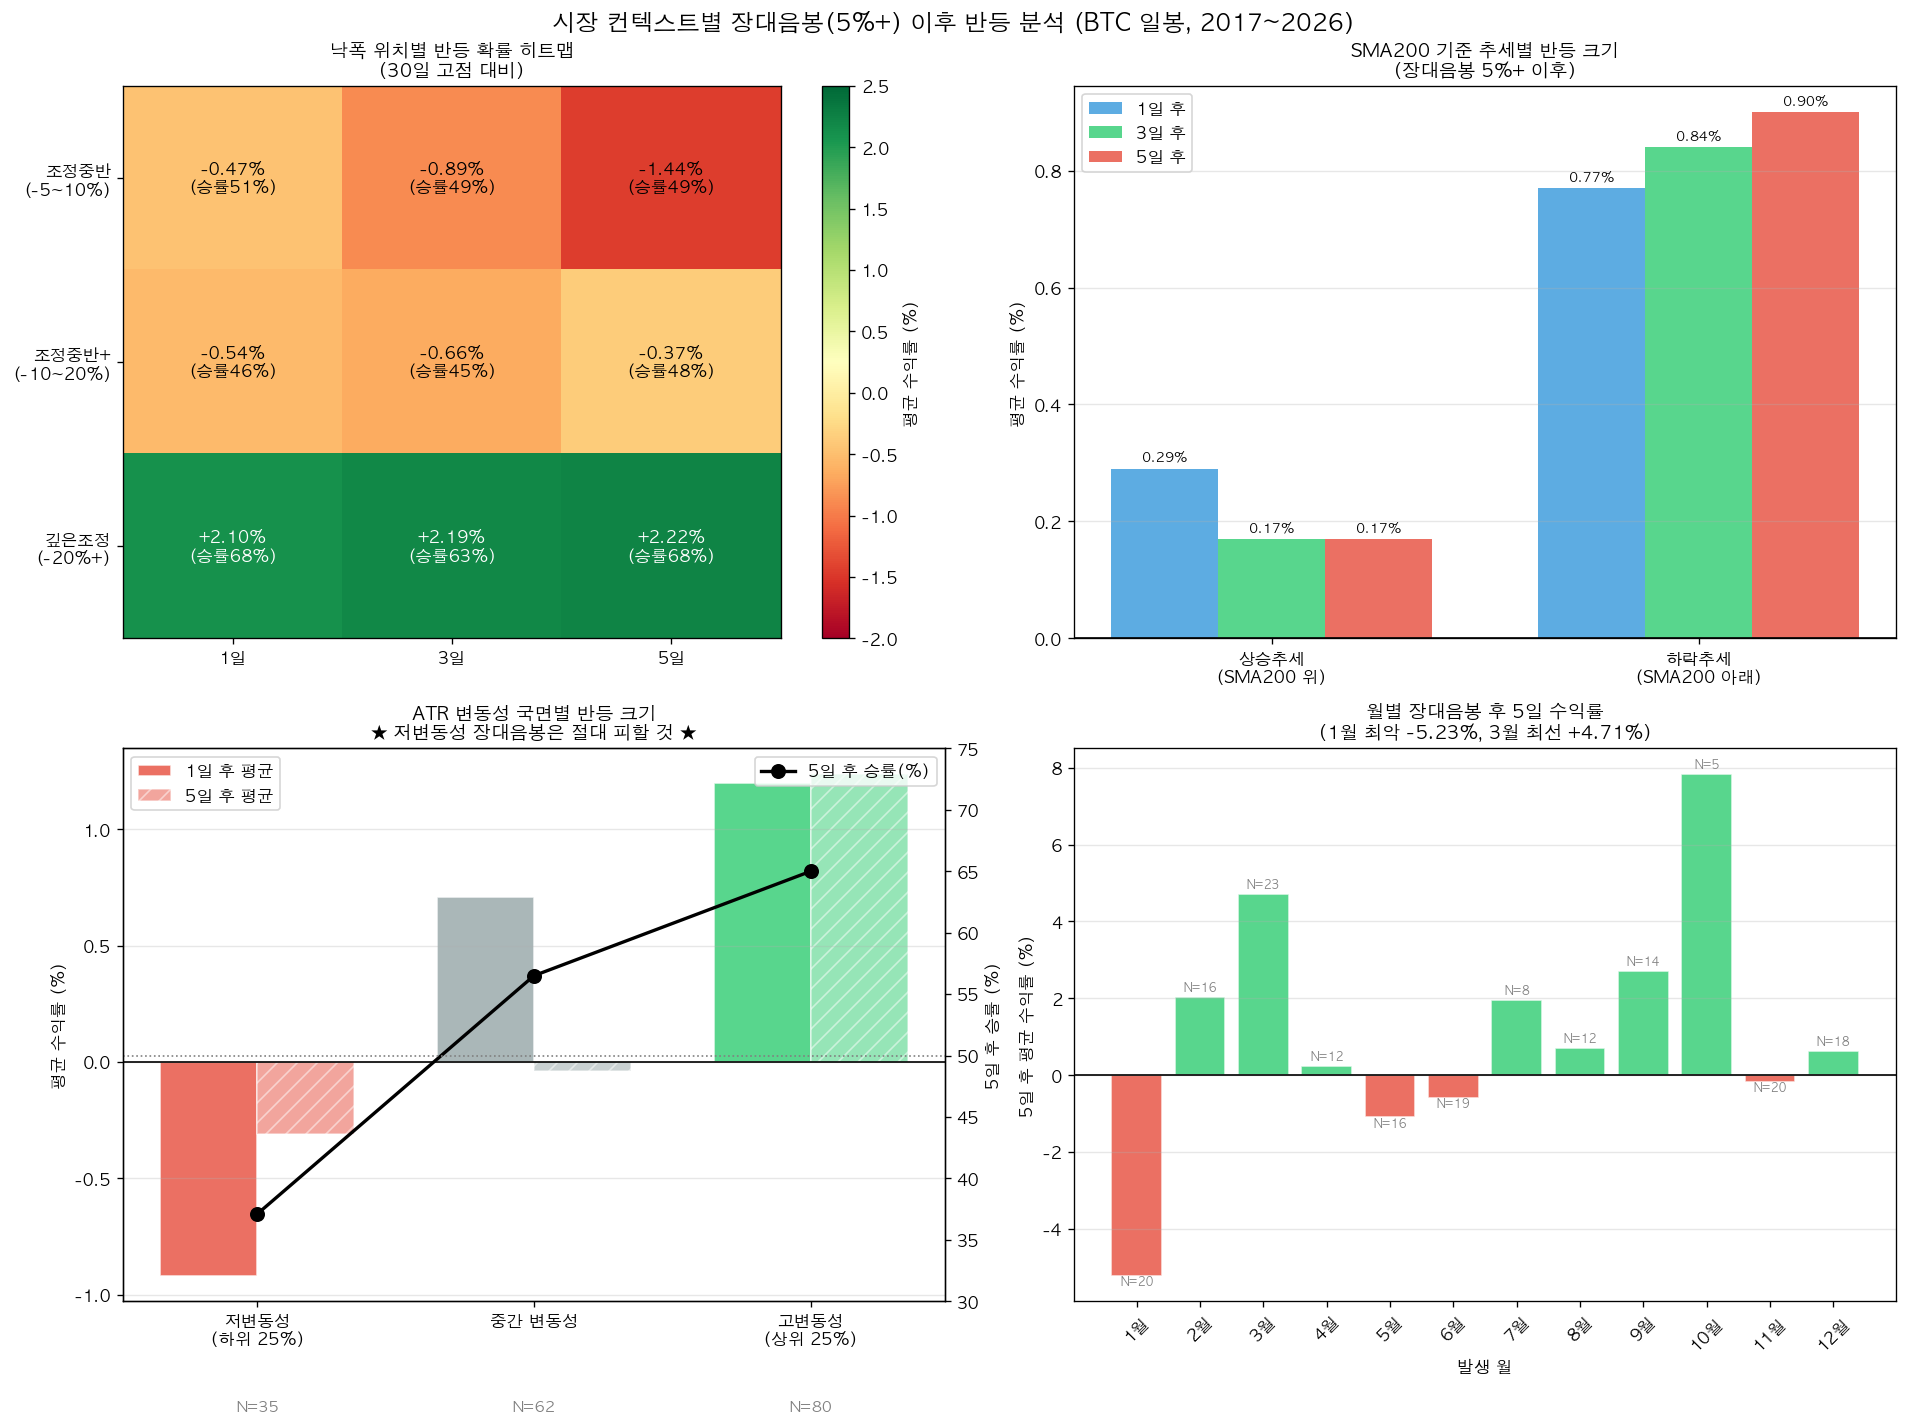


[핵심 인사이트]
- 최강 조합: 하락추세+깊은조정(-20%+)+고변동성 → 5d +5.26%, 승률 83.3% (N=30)
- 1월 장대음봉: 5d avg -5.23%, 승률 30% — 절대 금지 구간
- 3월 장대음봉: 5d avg +4.71%, 승률 78.3% — 최선 월
- 저변동성 장대음봉: 3d -2.31%, 승률 37.1% — 반드시 피해야 함


In [5]:
# 낙폭 위치별 반등 확률 히트맵 (Agent 3 연구 결과)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('시장 컨텍스트별 장대음봉(5%+) 이후 반등 분석 (BTC 일봉, 2017~2026)',
             fontsize=14, fontweight='bold')

# --- 패널 1: 낙폭 위치별 반등 (히트맵 스타일) ---
ax1 = axes[0][0]
drawdown_labels = ['조정중반\n(-5~10%)', '조정중반+\n(-10~20%)', '깊은조정\n(-20%+)']
periods_lbl = ['1일', '3일', '5일']
heatmap_data = np.array([
    [-0.47, -0.89, -1.44],  # -5~10%
    [-0.54, -0.66, -0.37],  # -10~20%
    [+2.10, +2.19, +2.22],  # -20%+
])
win_data = np.array([
    [51.4, 48.6, 48.6],
    [46.3, 44.8, 47.8],
    [68.4, 63.2, 68.4],
])

im = ax1.imshow(heatmap_data, cmap='RdYlGn', vmin=-2, vmax=2.5, aspect='auto')
ax1.set_xticks(range(3))
ax1.set_xticklabels(periods_lbl)
ax1.set_yticks(range(3))
ax1.set_yticklabels(drawdown_labels)
for i in range(3):
    for j in range(3):
        text = ax1.text(j, i, f'{heatmap_data[i,j]:+.2f}%\n(승률{win_data[i,j]:.0f}%)',
                        ha='center', va='center', fontsize=10, fontweight='bold',
                        color='white' if abs(heatmap_data[i,j]) > 1.5 else 'black')
ax1.set_title('낙폭 위치별 반등 확률 히트맵\n(30일 고점 대비)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax1, label='평균 수익률 (%)')

# --- 패널 2: SMA200 위/아래 비교 ---
ax2 = axes[0][1]
sma_categories = ['상승추세\n(SMA200 위)', '하락추세\n(SMA200 아래)']
sma_1d = [0.29, 0.77]
sma_3d = [0.17, 0.84]
sma_5d = [0.17, 0.90]
sma_win_5d = [56.5, 57.9]

x = np.arange(len(sma_categories))
width = 0.25
ax2.bar(x - width, sma_1d, width, label='1일 후', color='#3498db', alpha=0.8)
ax2.bar(x, sma_3d, width, label='3일 후', color='#2ecc71', alpha=0.8)
ax2.bar(x + width, sma_5d, width, label='5일 후', color='#e74c3c', alpha=0.8)
ax2.set_title('SMA200 기준 추세별 반등 크기\n(장대음봉 5%+ 이후)', fontsize=11, fontweight='bold')
ax2.set_ylabel('평균 수익률 (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(sma_categories)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
for xi, (v1, v3, v5) in zip(x, zip(sma_1d, sma_3d, sma_5d)):
    ax2.text(xi - width, v1 + 0.01, f'{v1:.2f}%', ha='center', va='bottom', fontsize=8)
    ax2.text(xi, v3 + 0.01, f'{v3:.2f}%', ha='center', va='bottom', fontsize=8)
    ax2.text(xi + width, v5 + 0.01, f'{v5:.2f}%', ha='center', va='bottom', fontsize=8)
ax2.axhline(0, color='black', linewidth=1)

# --- 패널 3: 변동성 국면별 ---
ax3 = axes[1][0]
vol_categories = ['저변동성\n(하위 25%)', '중간 변동성', '고변동성\n(상위 25%)']
vol_n = [35, 62, 80]
vol_1d = [-0.92, 0.71, 1.20]
vol_5d = [-0.31, -0.04, 1.24]
vol_win5 = [37.1, 56.5, 65.0]
vol_colors = ['#e74c3c', '#95a5a6', '#2ecc71']

x = np.arange(len(vol_categories))
width = 0.35
bars3a = ax3.bar(x - width/2, vol_1d, width, label='1일 후 평균', color=vol_colors, alpha=0.8, edgecolor='white')
bars3b = ax3.bar(x + width/2, vol_5d, width, label='5일 후 평균', color=vol_colors, alpha=0.5, edgecolor='white', hatch='//')
ax3.axhline(0, color='black', linewidth=1)
ax3_twin = ax3.twinx()
ax3_twin.plot(x, vol_win5, 'ko-', linewidth=2, markersize=8, label='5일 후 승률(%)')
ax3_twin.axhline(50, color='gray', linestyle=':', linewidth=1)
ax3_twin.set_ylabel('5일 후 승률 (%)')
ax3_twin.set_ylim(30, 75)
ax3.set_title('ATR 변동성 국면별 반등 크기\n★ 저변동성 장대음봉은 절대 피할 것 ★', fontsize=11, fontweight='bold')
ax3.set_ylabel('평균 수익률 (%)')
ax3.set_xticks(x)
ax3.set_xticklabels(vol_categories)
for xi, n in zip(x, vol_n):
    ax3.text(xi, -1.5, f'N={n}', ha='center', fontsize=9, color='gray')
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')
ax3.grid(axis='y', alpha=0.3)

# --- 패널 4: 월별 계절성 ---
ax4 = axes[1][1]
months = ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']
month_n = [20, 16, 23, 12, 16, 19, 8, 12, 14, 5, 20, 18]
month_5d = [-5.23, 2.04, 4.71, 0.23, -1.10, -0.59, 1.95, 0.71, 2.71, 7.85, -0.18, 0.63]
month_win5 = [30.0, 62.5, 78.3, 58.3, 62.5, 63.2, 75.0, 50.0, 50.0, 60.0, 50.0, 55.6]
month_bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in month_5d]

bars4 = ax4.bar(months, month_5d, color=month_bar_colors, edgecolor='white', alpha=0.8)
ax4.axhline(0, color='black', linewidth=1)
ax4.set_title('월별 장대음봉 후 5일 수익률\n(1월 최악 -5.23%, 3월 최선 +4.71%)', fontsize=11, fontweight='bold')
ax4.set_ylabel('5일 후 평균 수익률 (%)')
ax4.set_xlabel('발생 월')
ax4.tick_params(axis='x', rotation=45)
for bar, val, n in zip(bars4, month_5d, month_n):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.1 if val >= 0 else -0.3),
             f'N={n}', ha='center', va='bottom', fontsize=7, color='gray')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n[핵심 인사이트]')
print('- 최강 조합: 하락추세+깊은조정(-20%+)+고변동성 → 5d +5.26%, 승률 83.3% (N=30)')
print('- 1월 장대음봉: 5d avg -5.23%, 승률 30% — 절대 금지 구간')
print('- 3월 장대음봉: 5d avg +4.71%, 승률 78.3% — 최선 월')
print('- 저변동성 장대음봉: 3d -2.31%, 승률 37.1% — 반드시 피해야 함')

---
## 섹션 5: 봉 품질 분석

### 분석 개요
장대음봉의 형태적 특성(Body Ratio, 거래량, 꼬리 크기)과 이후 반등의 관계를 분석한다.

**Agent 4 핵심 발견:**
- Body Ratio ≥ 0.85 + 거래량 ≥ 2배: 1일 후 +6.99%, 승률 83.3% (N=6)
- **아래꼬리 길수록 반등 강하다는 직관이 틀림** — 데이터로 기각
- 거래량 급증(≥2배)이 3일 후 반등의 가장 신뢰성 있는 신호

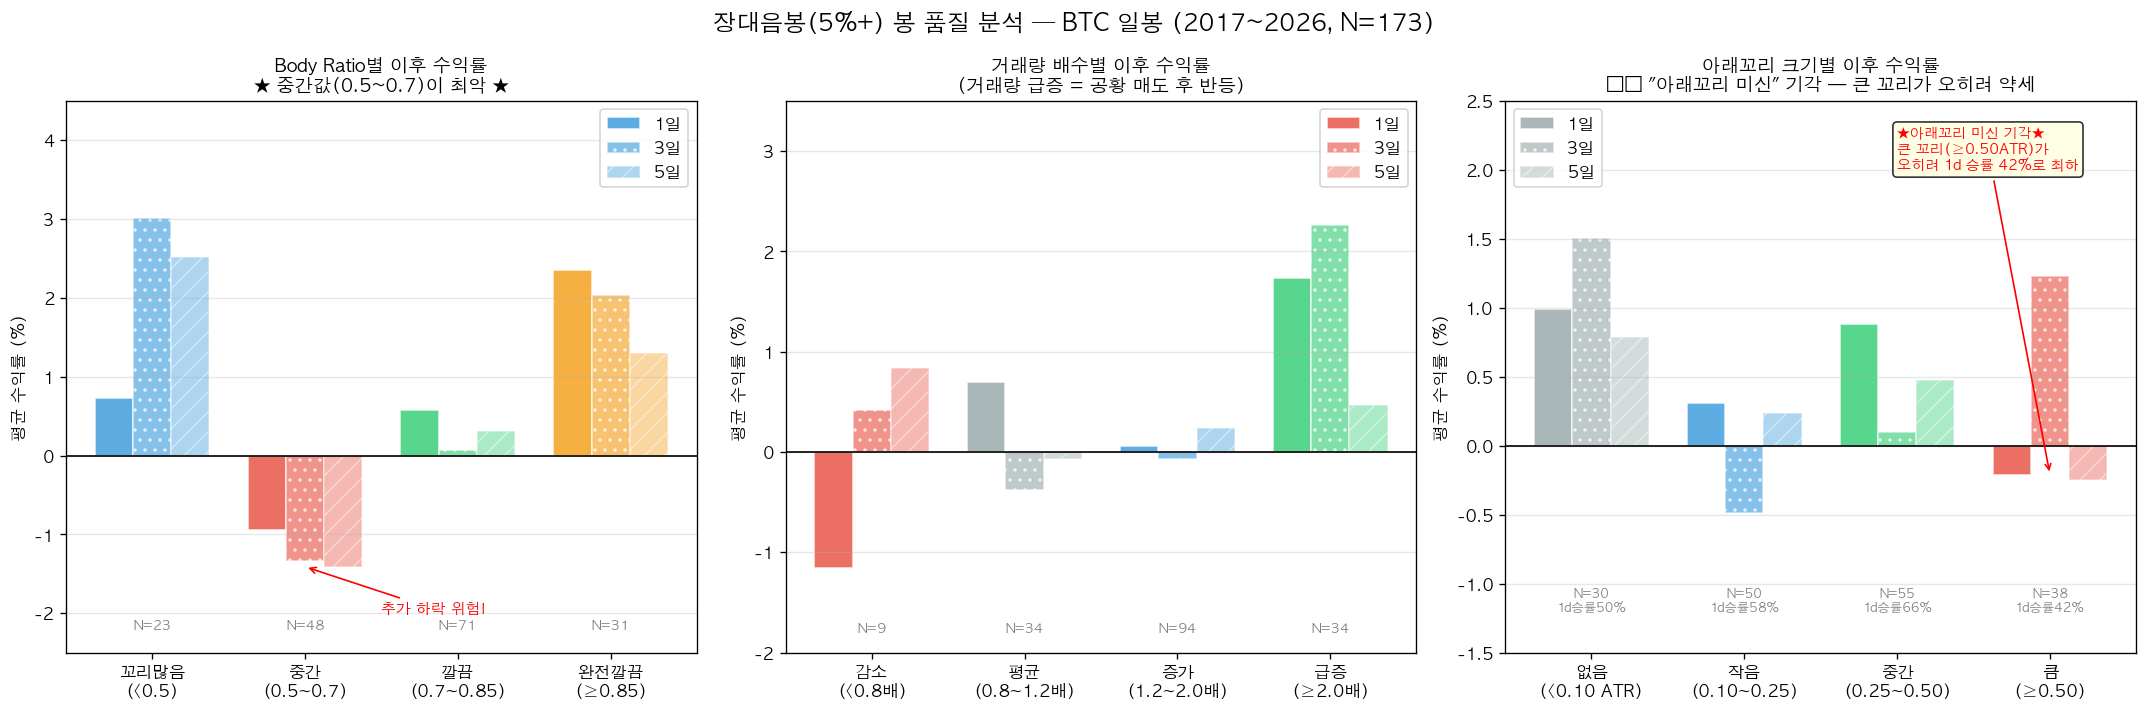


[핵심 인사이트]
- 아래꼬리 "미신" 기각: 아래꼬리가 클수록 1일 후 승률이 낮아짐 (42.1%)
- Body Ratio 중간값(0.5~0.7): 1d -0.94%, 5d -1.41% — 추가 하락 위험 신호
- 거래량 급증(≥2배): 3일 후 +2.26% (공황 매도 후 반등 가설 부분 지지)
- 최강 조건: Body≥0.85 + 거래량≥2배 → 1d +6.99%, 83.3% (N=6, 역사적 저점)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('장대음봉(5%+) 봉 품질 분석 — BTC 일봉 (2017~2026, N=173)',
             fontsize=14, fontweight='bold')

# --- 패널 1: Body Ratio별 이후 수익률 ---
ax1 = axes[0]
body_labels = ['꼬리많음\n(<0.5)', '중간\n(0.5~0.7)', '깔끔\n(0.7~0.85)', '완전깔끔\n(≥0.85)']
body_n = [23, 48, 71, 31]
body_1d = [0.73, -0.94, 0.58, 2.35]
body_3d = [3.02, -1.34, 0.07, 2.04]
body_5d = [2.52, -1.41, 0.31, 1.30]
body_win1 = [56.5, 37.5, 62.0, 67.7]

x = np.arange(len(body_labels))
width = 0.25
body_bar_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
ax1.bar(x - width, body_1d, width, label='1일', color=body_bar_colors, alpha=0.8, edgecolor='white')
ax1.bar(x, body_3d, width, label='3일', color=body_bar_colors, alpha=0.6, edgecolor='white', hatch='..')
ax1.bar(x + width, body_5d, width, label='5일', color=body_bar_colors, alpha=0.4, edgecolor='white', hatch='//')
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title('Body Ratio별 이후 수익률\n★ 중간값(0.5~0.7)이 최악 ★', fontsize=11, fontweight='bold')
ax1.set_ylabel('평균 수익률 (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(body_labels)
for xi, n in zip(x, body_n):
    ax1.text(xi, -2.2, f'N={n}', ha='center', fontsize=8, color='gray')
ax1.legend()
ax1.set_ylim(-2.5, 4.5)
ax1.grid(axis='y', alpha=0.3)

# 추가 주석
ax1.annotate('추가 하락 위험!', xy=(1, -1.41), xytext=(1.5, -2.0),
             fontsize=9, color='red', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red'))

# --- 패널 2: 거래량 배수별 이후 수익률 ---
ax2 = axes[1]
vol_labels = ['감소\n(<0.8배)', '평균\n(0.8~1.2배)', '증가\n(1.2~2.0배)', '급증\n(≥2.0배)']
vol_n = [9, 34, 94, 34]
vol_1d = [-1.16, 0.70, 0.06, 1.74]
vol_3d = [0.42, -0.38, -0.07, 2.26]
vol_5d = [0.84, -0.07, 0.24, 0.47]
vol_win3 = [66.7, 52.9, 48.9, 55.9]
vol_bar_colors = ['#e74c3c', '#95a5a6', '#3498db', '#2ecc71']

x = np.arange(len(vol_labels))
ax2.bar(x - width, vol_1d, width, label='1일', color=vol_bar_colors, alpha=0.8, edgecolor='white')
ax2.bar(x, vol_3d, width, label='3일', color=vol_bar_colors, alpha=0.6, edgecolor='white', hatch='..')
ax2.bar(x + width, vol_5d, width, label='5일', color=vol_bar_colors, alpha=0.4, edgecolor='white', hatch='//')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('거래량 배수별 이후 수익률\n(거래량 급증 = 공황 매도 후 반등)', fontsize=11, fontweight='bold')
ax2.set_ylabel('평균 수익률 (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(vol_labels)
for xi, n in zip(x, vol_n):
    ax2.text(xi, -1.8, f'N={n}', ha='center', fontsize=8, color='gray')
ax2.legend()
ax2.set_ylim(-2.0, 3.5)
ax2.grid(axis='y', alpha=0.3)

# --- 패널 3: 아래꼬리 크기별 이후 수익률 (미신 기각) ---
ax3 = axes[2]
wick_labels = ['없음\n(<0.10 ATR)', '작음\n(0.10~0.25)', '중간\n(0.25~0.50)', '큼\n(≥0.50)']
wick_n = [30, 50, 55, 38]
wick_1d = [0.99, 0.31, 0.88, -0.21]
wick_3d = [1.51, -0.49, 0.10, 1.23]
wick_5d = [0.79, 0.24, 0.48, -0.25]
wick_win1 = [50.0, 58.0, 65.5, 42.1]
wick_bar_colors = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c']

x = np.arange(len(wick_labels))
ax3.bar(x - width, wick_1d, width, label='1일', color=wick_bar_colors, alpha=0.8, edgecolor='white')
ax3.bar(x, wick_3d, width, label='3일', color=wick_bar_colors, alpha=0.6, edgecolor='white', hatch='..')
ax3.bar(x + width, wick_5d, width, label='5일', color=wick_bar_colors, alpha=0.4, edgecolor='white', hatch='//')
ax3.axhline(0, color='black', linewidth=1)
ax3.set_title('아래꼬리 크기별 이후 수익률\n⚠️ "아래꼬리 미신" 기각 — 큰 꼬리가 오히려 약세', fontsize=11, fontweight='bold')
ax3.set_ylabel('평균 수익률 (%)')
ax3.set_xticks(x)
ax3.set_xticklabels(wick_labels)
for xi, (n, w) in enumerate(zip(wick_n, wick_win1)):
    ax3.text(xi, -1.2, f'N={n}\n1d승률{w:.0f}%', ha='center', fontsize=7.5, color='gray')
ax3.legend()
ax3.set_ylim(-1.5, 2.5)
ax3.grid(axis='y', alpha=0.3)

# 기각 표시
ax3.annotate('★아래꼬리 미신 기각★\n큰 꼬리(≥0.50ATR)가\n오히려 1d 승률 42%로 최하',
             xy=(3, -0.21), xytext=(2.0, 2.0),
             fontsize=8.5, color='red', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red'),
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print('\n[핵심 인사이트]')
print('- 아래꼬리 "미신" 기각: 아래꼬리가 클수록 1일 후 승률이 낮아짐 (42.1%)')
print('- Body Ratio 중간값(0.5~0.7): 1d -0.94%, 5d -1.41% — 추가 하락 위험 신호')
print('- 거래량 급증(≥2배): 3일 후 +2.26% (공황 매도 후 반등 가설 부분 지지)')
print('- 최강 조건: Body≥0.85 + 거래량≥2배 → 1d +6.99%, 83.3% (N=6, 역사적 저점)')

---
## 섹션 6: 코인별 비교

### 분석 개요
BTC/ETH/BNB/SOL의 급락 후 반등 패턴을 비교하고, BTC 급락 시 알트코인 Decoupling 케이스를 분석한다.

**Agent 6 핵심 발견:**
- **BNB 1위**: 5일 후 +4.08%, 승률 62% — 반등 전략 최적 코인
- **SOL 4위**: 급락 빈도 13%, 1일 승률 52% — 반등 전략 부적합
- BTC 급락 시 ETH Decoupling(버팀): 5일 후 +9.42% 최고 수익률 (희귀)

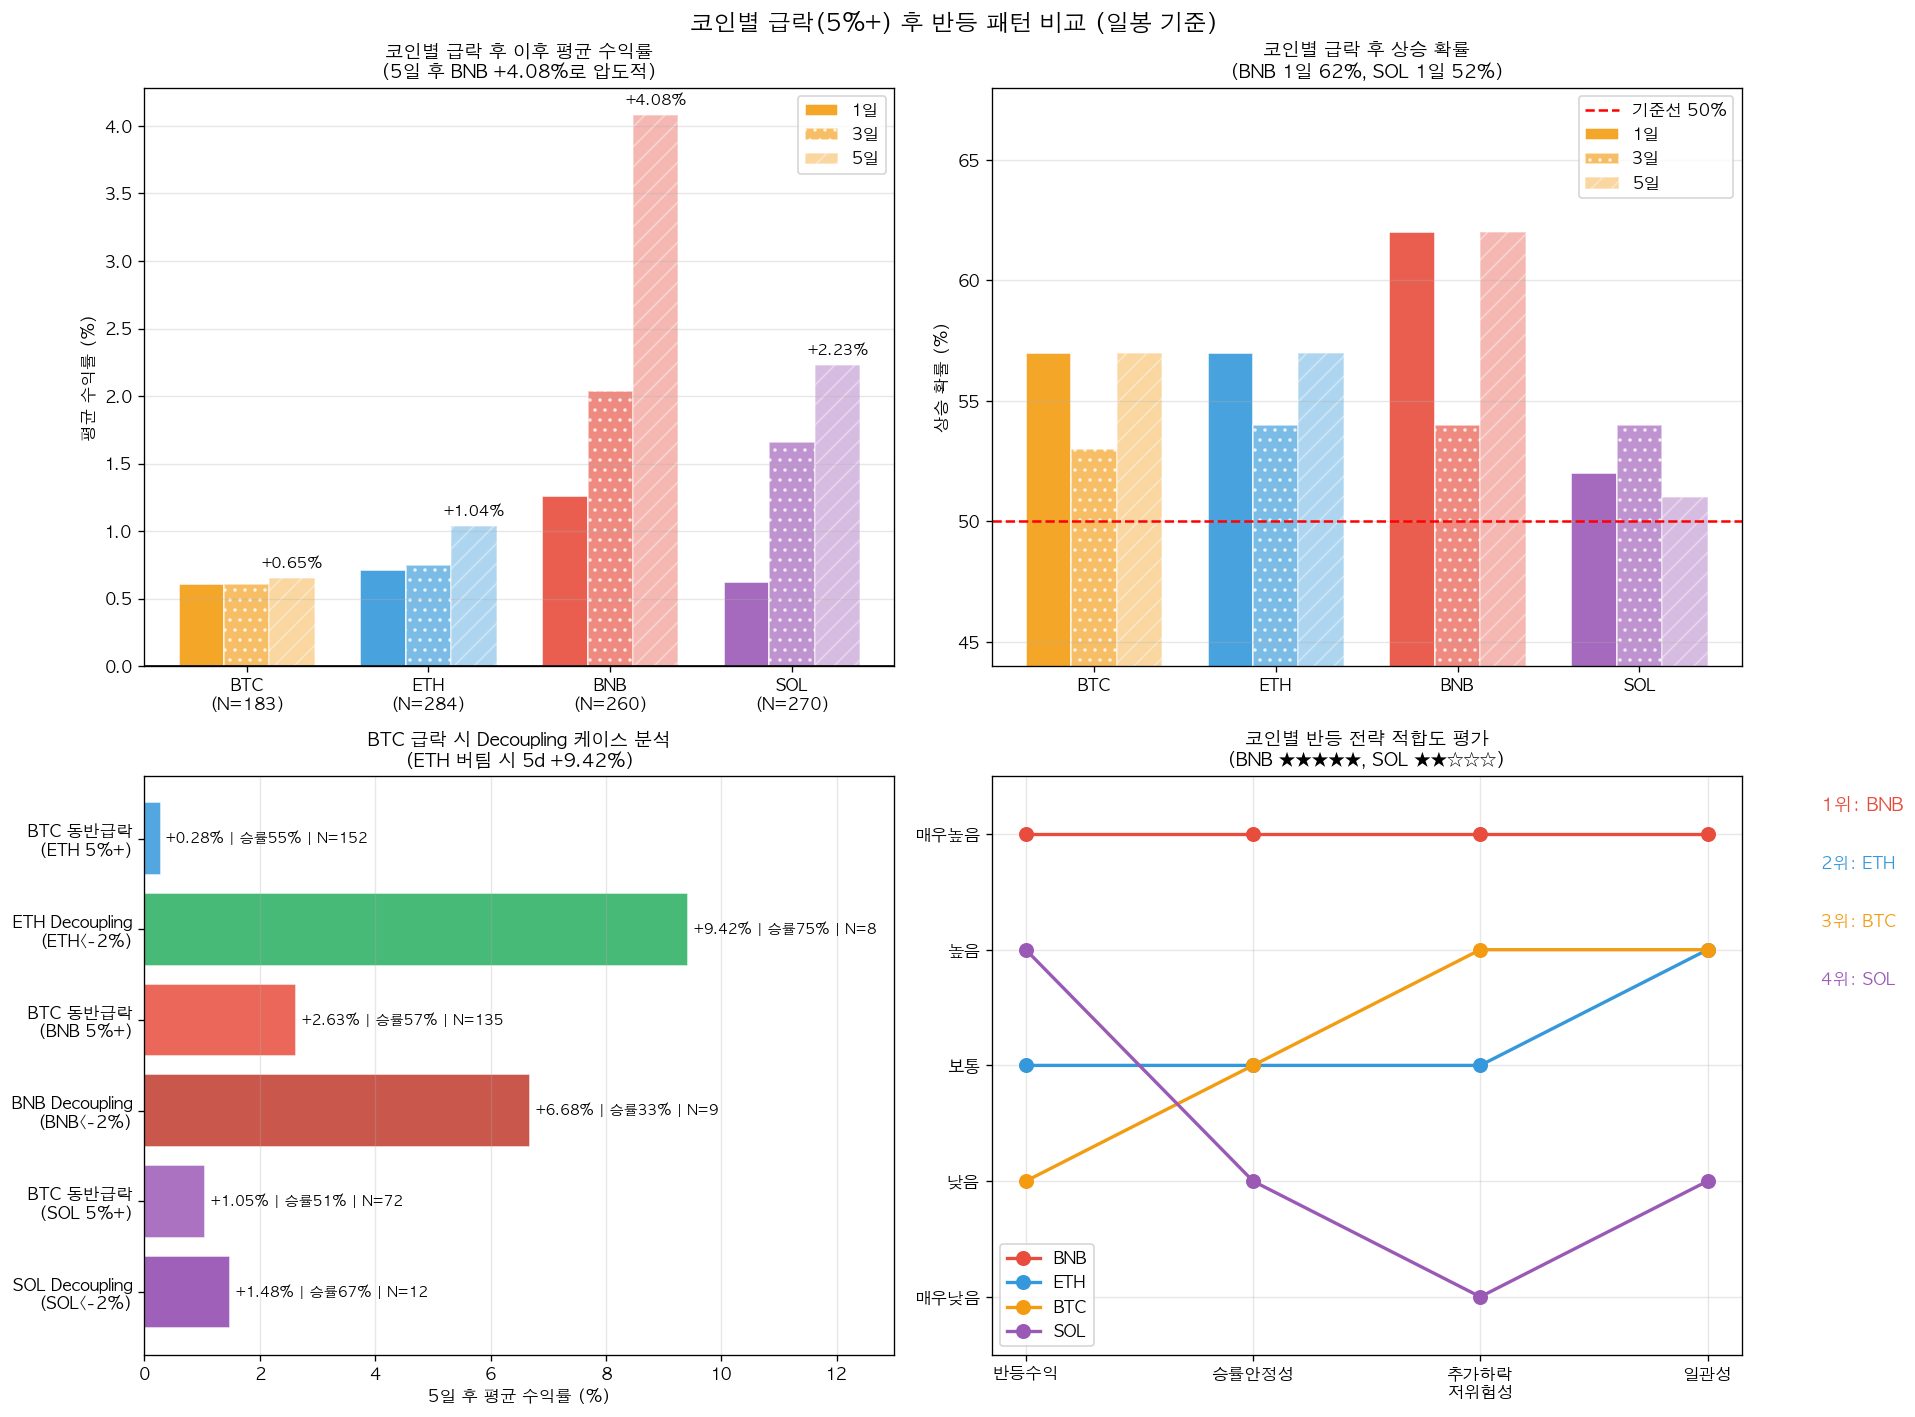


[코인별 종합 평가]
1위 BNB ★★★★★: 5일 +4.08%, 승률 62%, 추가하락 최저(24%). 반등 전략 최적
2위 ETH ★★★☆☆: 5일 +1.04%, 승률 57%. 상승장+BTC급락시 Decoupling 노릴 것
3위 BTC ★★★☆☆: 5일 +0.65%, 승률 57%. 10%+급락만 의미있음
4위 SOL ★★☆☆☆: 급락빈도 13%, 1일승률 52%. 반등전략 부적합


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('코인별 급락(5%+) 후 반등 패턴 비교 (일봉 기준)',
             fontsize=14, fontweight='bold')

# --- 패널 1: 코인별 1/3/5일 평균 수익률 ---
ax1 = axes[0][0]
coins = ['BTC', 'ETH', 'BNB', 'SOL']
coin_colors = ['#f39c12', '#3498db', '#e74c3c', '#9b59b6']
coin_n = [183, 284, 260, 270]
data_1d = [0.61, 0.71, 1.26, 0.62]
data_3d = [0.61, 0.75, 2.04, 1.66]
data_5d = [0.65, 1.04, 4.08, 2.23]

x = np.arange(len(coins))
width = 0.25
ax1.bar(x - width, data_1d, width, label='1일', color=coin_colors, alpha=0.9, edgecolor='white')
ax1.bar(x, data_3d, width, label='3일', color=coin_colors, alpha=0.65, edgecolor='white', hatch='..')
ax1.bar(x + width, data_5d, width, label='5일', color=coin_colors, alpha=0.4, edgecolor='white', hatch='//')
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title('코인별 급락 후 이후 평균 수익률\n(5일 후 BNB +4.08%로 압도적)', fontsize=11, fontweight='bold')
ax1.set_ylabel('평균 수익률 (%)')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{c}\n(N={n})' for c, n in zip(coins, coin_n)])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 5일 수익 레이블
for xi, v in zip(x + width, data_5d):
    ax1.text(xi, v + 0.05, f'+{v:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- 패널 2: 코인별 승률 비교 ---
ax2 = axes[0][1]
win_1d = [57, 57, 62, 52]
win_3d = [53, 54, 54, 54]
win_5d = [57, 57, 62, 51]

x = np.arange(len(coins))
ax2.bar(x - width, win_1d, width, label='1일', color=coin_colors, alpha=0.9, edgecolor='white')
ax2.bar(x, win_3d, width, label='3일', color=coin_colors, alpha=0.65, edgecolor='white', hatch='..')
ax2.bar(x + width, win_5d, width, label='5일', color=coin_colors, alpha=0.4, edgecolor='white', hatch='//')
ax2.axhline(50, color='red', linestyle='--', linewidth=1.5, label='기준선 50%')
ax2.set_title('코인별 급락 후 상승 확률\n(BNB 1일 62%, SOL 1일 52%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('상승 확률 (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(coins)
ax2.set_ylim(44, 68)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# --- 패널 3: BTC 급락 시 알트 Decoupling 분석 ---
ax3 = axes[1][0]
decouple_scenarios = [
    'BTC 동반급락\n(ETH 5%+)', 'ETH Decoupling\n(ETH<-2%)', 
    'BTC 동반급락\n(BNB 5%+)', 'BNB Decoupling\n(BNB<-2%)',
    'BTC 동반급락\n(SOL 5%+)', 'SOL Decoupling\n(SOL<-2%)'
]
decouple_n = [152, 8, 135, 9, 72, 12]
decouple_5d = [0.28, 9.42, 2.63, 6.68, 1.05, 1.48]
decouple_win5 = [55, 75, 57, 33, 51, 67]
decouple_colors = ['#3498db', '#27ae60', '#e74c3c', '#c0392b', '#9b59b6', '#8e44ad']

bars3 = ax3.barh(decouple_scenarios[::-1], decouple_5d[::-1], 
                 color=decouple_colors[::-1], edgecolor='white', alpha=0.85)
ax3.axvline(0, color='black', linewidth=1)
ax3.set_title('BTC 급락 시 Decoupling 케이스 분석\n(ETH 버팀 시 5d +9.42%)', fontsize=11, fontweight='bold')
ax3.set_xlabel('5일 후 평균 수익률 (%)')
for bar, val, n, win in zip(bars3, decouple_5d[::-1], decouple_n[::-1], decouple_win5[::-1]):
    ax3.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'+{val:.2f}% | 승률{win}% | N={n}', ha='left', va='center', fontsize=8.5)
ax3.set_xlim(0, 13)
ax3.grid(axis='x', alpha=0.3)

# --- 패널 4: 코인별 적합도 레이더/점수 ---
ax4 = axes[1][1]
rating_data = {
    '코인': ['BNB', 'ETH', 'BTC', 'SOL'],
    '반등수익': [5, 3, 2, 4],
    '승률안정성': [5, 3, 3, 2],
    '추가하락위험': [5, 3, 4, 1],  # 낮을수록 위험 (역수로 표현)
    '일관성': [5, 4, 4, 2],
    '종합': [5, 3, 3, 2],
}
df_rating = pd.DataFrame(rating_data)

categories = ['반등수익', '승률안정성', '추가하락\n저위험성', '일관성']
rating_colors_r = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6']
x = np.arange(len(categories))

for i, (coin, rc) in enumerate(zip(['BNB', 'ETH', 'BTC', 'SOL'], rating_colors_r)):
    row = df_rating[df_rating['코인'] == coin].iloc[0]
    vals = [row['반등수익'], row['승률안정성'], row['추가하락위험'], row['일관성']]
    ax4.plot(x, vals, 'o-', color=rc, label=coin, linewidth=2, markersize=8)

ax4.set_xticks(x)
ax4.set_xticklabels(categories)
ax4.set_yticks([1, 2, 3, 4, 5])
ax4.set_yticklabels(['매우낮음', '낮음', '보통', '높음', '매우높음'])
ax4.set_title('코인별 반등 전략 적합도 평가\n(BNB ★★★★★, SOL ★★☆☆☆)', fontsize=11, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)
ax4.set_ylim(0.5, 5.5)

# 순위 텍스트
ax4.text(3.5, 5.2, '1위: BNB', fontsize=11, color='#e74c3c', fontweight='bold')
ax4.text(3.5, 4.7, '2위: ETH', fontsize=10, color='#3498db')
ax4.text(3.5, 4.2, '3위: BTC', fontsize=10, color='#f39c12')
ax4.text(3.5, 3.7, '4위: SOL', fontsize=10, color='#9b59b6')

plt.tight_layout()
plt.show()

print('\n[코인별 종합 평가]')
print('1위 BNB ★★★★★: 5일 +4.08%, 승률 62%, 추가하락 최저(24%). 반등 전략 최적')
print('2위 ETH ★★★☆☆: 5일 +1.04%, 승률 57%. 상승장+BTC급락시 Decoupling 노릴 것')
print('3위 BTC ★★★☆☆: 5일 +0.65%, 승률 57%. 10%+급락만 의미있음')
print('4위 SOL ★★☆☆☆: 급락빈도 13%, 1일승률 52%. 반등전략 부적합')

---
## 섹션 7: 최적 전략 파라미터 도출

### 6개 에이전트 결과 종합

| 에이전트 | 분석 영역 | 핵심 발견 | 전략 시사점 |
|---------|---------|---------|----------|
| Agent 1 | 음봉 기초 통계 | 중음봉(2~5%)이 5일 승률 57.5% 최고 / 3일 연속 음봉 시 승률 59.2% | 진입 문턱: 2% 이상 음봉 |
| Agent 2 | 진입 타이밍 | **T0 종가 즉시 진입** 최강 (+0.65%/57.4%) / 양봉 대기는 역효과 | 음봉 당일 종가에 즉시 매수 |
| Agent 3 | 시장 컨텍스트 | 하락추세+깊은조정+고변동성 → 83.3% 승률 / 저변동성 금지 | SMA200 + 낙폭 + ATR 필터 |
| Agent 4 | 봉 품질 분석 | Body≥0.85+거래량≥2배 → 83.3% 승률 / 아래꼬리 미신 기각 | Body Ratio + 거래량 필터 |
| Agent 5 | 타임프레임 비교 | 일봉 EV +0.39% / 4h EV -0.31% / 최적 TP=5%/SL=3%/max=10일 | **일봉만 사용** / TP5/SL3 |
| Agent 6 | 코인별 비교 | BNB 5일 +4.08% 최강 / SOL 부적합 / BNB 상승장 64% 승률 | **BNB 집중** / ETH 보조 |

---

### 확정 파라미터 정리

#### 급락 반등 전략 (Reversal Strategy)

**진입 조건 (스코어 방식):**

| 조건 | 점수 | 필수/선택 |
|------|------|----------|
| 일봉 body 하락 ≥ 5% | 2점 | 필수 |
| SMA200 아래 (하락추세) | 1점 | 권장 |
| 30일 고점 대비 -20%+ 낙폭 | 2점 | 강화 |
| ATR 상위 25% (고변동성) | 1점 | 강화 |
| 거래량 ≥ 2배 | 1점 | 강화 |
| Body Ratio ≥ 0.85 | 1점 | 강화 |
| 직전 장대음봉 존재 | 1점 | 강화 |
| body 하락 ≥ 10% | 2점 | 초강화 |

**권장:** 4점 이상 시 진입

**파라미터:**
- 타임프레임: **1일봉 (일봉)**
- 진입 타이밍: **음봉 당일 종가 즉시 매수**
- 손절(SL): **3%** (진입가 대비)
- 익절(TP): **5%** (EV 최고)
- 최대 보유: **10일** (대부분 10일 내 결론)
- 우선 코인: **BNB > ETH > BTC** (SOL 제외)

**회피 조건:**
- SMA200 위 + 30일 고점 대비 -15% 미만 낙폭 (방향 불명확)
- ATR 하위 25% (저변동성 장대음봉 — 3d 승률 37%)
- 1월 발생 (5d avg -5.23%)
- Body Ratio 0.5~0.7 (추가 하락 신호)
- 4h봉 기준 신호 (엣지 없음, EV -0.31%)

---

### 장대양봉 전략(jangdae_momentum)과의 비교 및 보완 관계

| 항목 | 장대양봉 전략 (기존 최강) | 급락 반등 전략 (신규) |
|------|----------------------|-------------------|
| 컨셉 | 강세 모멘텀 추종 | 과매도 반등 포착 |
| 진입 | 장대양봉 다음날 첫 양봉 | 장대음봉 당일 종가 |
| OOS Sharpe | 1.29 | 미검증 (EV 기반 추정) |
| 5일 EV | 높음 (OOS 검증됨) | +0.39%~+5.26% (컨텍스트 의존) |
| SMA200 | 위에서만 진입 (강세장) | 아래에서 더 강함 (하락장 반등) |
| 적합 시장 | 강세장 (2020-2021형) | 하락장 바닥 (2020-03형) |
| 거래 빈도 | 연 25~30건 | 연 10~20건 (5%+ 급락) |
| **보완성** | **서로 다른 국면에서 수익** | **포트폴리오 헤지 효과** |

**핵심 결론:**
- 두 전략은 **강세/약세 국면을 각각 커버** → 포트폴리오 변동성 감소
- 장대양봉 전략이 OOS 검증 완료 → 실거래 우선
- 급락 반등 전략은 **BNB 상승장+고낙폭 조건 충족 시** 보조 전략으로 활용
- 현재(2026-04) 하락장 분위기: 반등 전략보다 SMA200 복귀 확인 후 장대양봉 전략 유지

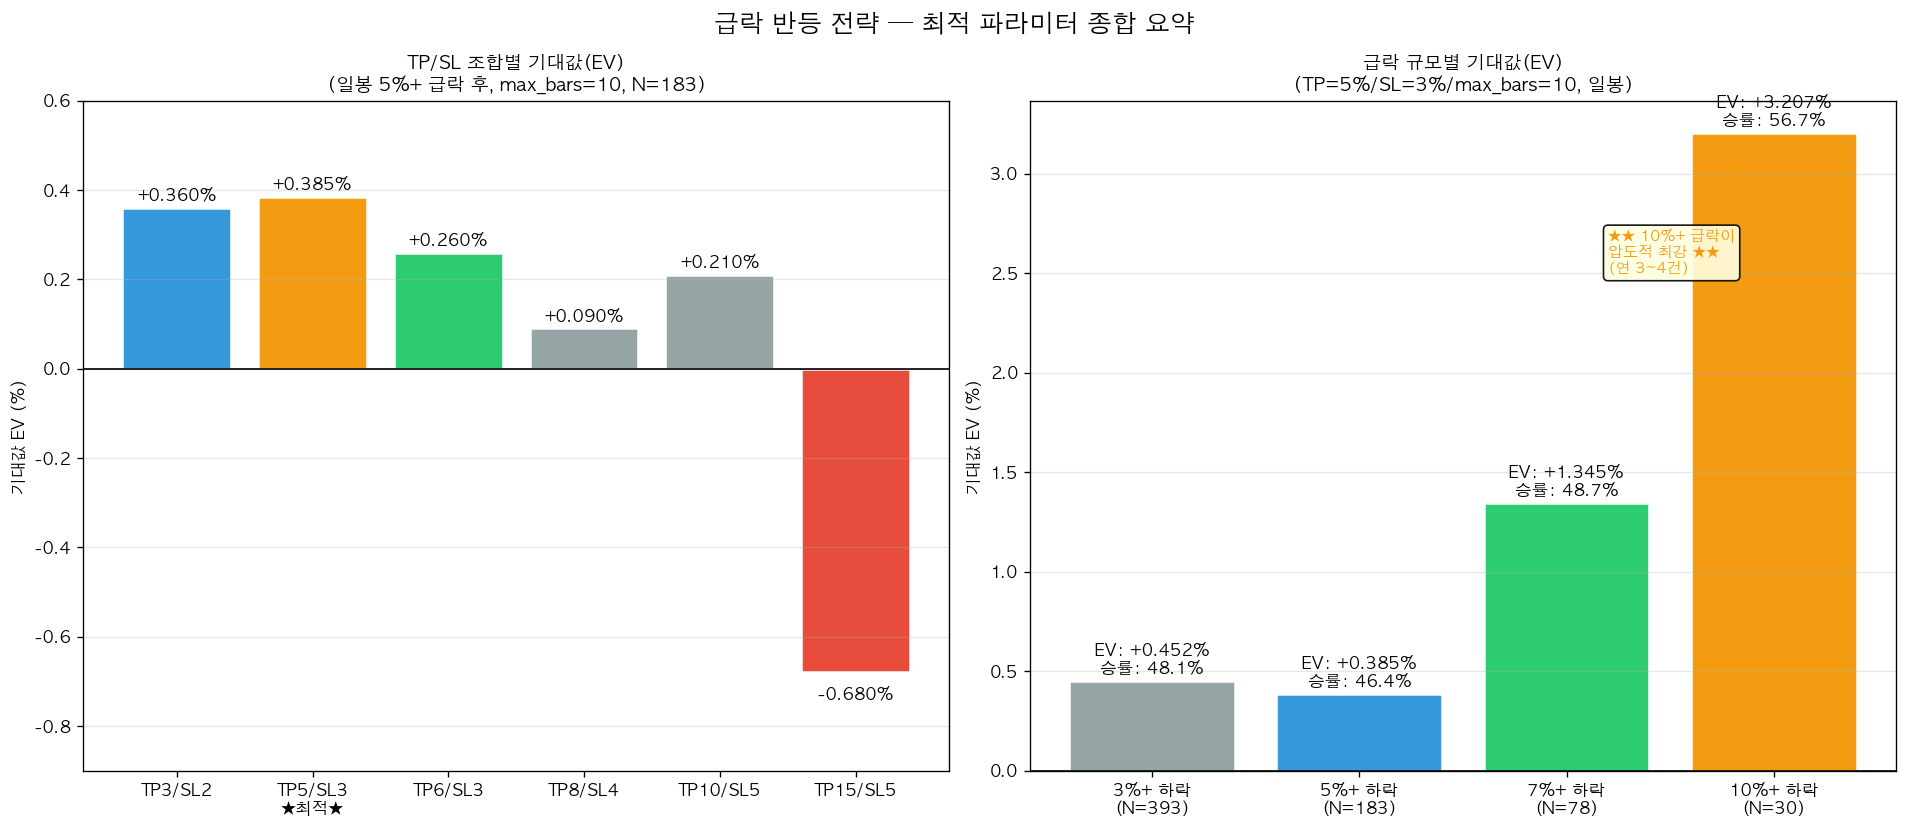

급락 반등 전략 — 확정 파라미터 최종 요약

[기본 설정]
  타임프레임: 일봉 (1d)  ← 4h는 엣지 없음
  진입 타이밍: 음봉 당일 종가 즉시 매수  ← T0 최강
  손절(SL): 3%  |  익절(TP): 5%  |  최대 보유: 10일

[진입 필터 (스코어 4점 이상 권장)]
  필수 (2점): body 하락 ≥ 5%
  강화 (2점): 30일 고점 대비 -20%+ 낙폭
  강화 (1점): SMA200 아래 (하락추세)
  강화 (1점): ATR 상위 25% (고변동성)
  강화 (1점): 거래량 ≥ 2배
  초강화(2점): body 하락 ≥ 10%

[우선 코인]
  1위: BNB (5d +4.08%, 승률 62%)
  2위: ETH (5d +1.04%, 승률 57%)
  3위: BTC (10%+급락만, 5d +2.58%, 승률 57%)
  제외: SOL (1d 승률 52%, 동전 던지기 수준)

[회피 조건]
  - 1월 발생 (5d avg -5.23%)
  - ATR 하위 25% (저변동성)
  - Body Ratio 0.5~0.7 (중간값 — 추가 하락 위험)
  - SMA200 위 + 낙폭 -15% 미만 (방향 불명확)

[현재(2026-04) 시장 판단]
  → 전 코인 반등 패턴 약함. 현재는 추세 추종(ensemble) 유지 권장
  → 재개 조건: BTC > SMA200 복귀 + 전 코인 SMA200 위 확인 후


In [8]:
# 최적 파라미터 시각화 요약
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('급락 반등 전략 — 최적 파라미터 종합 요약', fontsize=15, fontweight='bold')

# --- 패널 1: TP/SL 조합별 EV ---
ax1 = axes[0]
tpsl_labels = ['TP3/SL2', 'TP5/SL3\n★최적★', 'TP6/SL3', 'TP8/SL4', 'TP10/SL5', 'TP15/SL5']
tpsl_ev = [0.36, 0.385, 0.26, 0.09, 0.21, -0.68]
tpsl_win = [48.6, 46.4, 43.7, 43.7, 47.0, 42.1]
tpsl_kelly = [0.052, 0.046, 0.030, 0.010, 0.022, -0.071]
tpsl_colors = ['#3498db', '#f39c12', '#2ecc71', '#95a5a6', '#95a5a6', '#e74c3c']

bars1 = ax1.bar(tpsl_labels, tpsl_ev, color=tpsl_colors, edgecolor='white', linewidth=1.5)
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title('TP/SL 조합별 기대값(EV)\n(일봉 5%+ 급락 후, max_bars=10, N=183)', fontsize=11, fontweight='bold')
ax1.set_ylabel('기대값 EV (%)')
for bar, val in zip(bars1, tpsl_ev):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.01 if val >= 0 else -0.03),
             f'{val:+.3f}%', ha='center',
             va='bottom' if val >= 0 else 'top', fontsize=10, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(-0.9, 0.6)

# --- 패널 2: 급락 규모별 EV (일봉) ---
ax2 = axes[1]
size_labels = ['3%+ 하락\n(N=393)', '5%+ 하락\n(N=183)', '7%+ 하락\n(N=78)', '10%+ 하락\n(N=30)']
size_ev = [0.452, 0.385, 1.345, 3.207]
size_win = [48.1, 46.4, 48.7, 56.7]
size_colors = ['#95a5a6', '#3498db', '#2ecc71', '#f39c12']

bars2 = ax2.bar(size_labels, size_ev, color=size_colors, edgecolor='white', linewidth=1.5)
ax2.set_title('급락 규모별 기대값(EV)\n(TP=5%/SL=3%/max_bars=10, 일봉)', fontsize=11, fontweight='bold')
ax2.set_ylabel('기대값 EV (%)')
ax2.axhline(0, color='black', linewidth=1)
for bar, val, win in zip(bars2, size_ev, size_win):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'EV: +{val:.3f}%\n승률: {win:.1f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 강조 박스
ax2.annotate('★★ 10%+ 급락이\n압도적 최강 ★★\n(연 3~4건)',
             xy=(3, 3.207), xytext=(2.2, 2.5),
             fontsize=9, color='#f39c12', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#f39c12'),
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()

# 최종 요약 출력
print('=' * 70)
print('급락 반등 전략 — 확정 파라미터 최종 요약')
print('=' * 70)
print()
print('[기본 설정]')
print('  타임프레임: 일봉 (1d)  ← 4h는 엣지 없음')
print('  진입 타이밍: 음봉 당일 종가 즉시 매수  ← T0 최강')
print('  손절(SL): 3%  |  익절(TP): 5%  |  최대 보유: 10일')
print()
print('[진입 필터 (스코어 4점 이상 권장)]')
print('  필수 (2점): body 하락 ≥ 5%')
print('  강화 (2점): 30일 고점 대비 -20%+ 낙폭')
print('  강화 (1점): SMA200 아래 (하락추세)')
print('  강화 (1점): ATR 상위 25% (고변동성)')
print('  강화 (1점): 거래량 ≥ 2배')
print('  초강화(2점): body 하락 ≥ 10%')
print()
print('[우선 코인]')
print('  1위: BNB (5d +4.08%, 승률 62%)')
print('  2위: ETH (5d +1.04%, 승률 57%)')
print('  3위: BTC (10%+급락만, 5d +2.58%, 승률 57%)')
print('  제외: SOL (1d 승률 52%, 동전 던지기 수준)')
print()
print('[회피 조건]')
print('  - 1월 발생 (5d avg -5.23%)')
print('  - ATR 하위 25% (저변동성)')
print('  - Body Ratio 0.5~0.7 (중간값 — 추가 하락 위험)')
print('  - SMA200 위 + 낙폭 -15% 미만 (방향 불명확)')
print()
print('[현재(2026-04) 시장 판단]')
print('  → 전 코인 반등 패턴 약함. 현재는 추세 추종(ensemble) 유지 권장')
print('  → 재개 조건: BTC > SMA200 복귀 + 전 코인 SMA200 위 확인 후')
print('=' * 70)

---
## 섹션 8: 전략 백테스트 — 코인별 자산 곡선

### 분석 개요
`jangdae_eumbon_reversal` 전략을 BTC/ETH/BNB/SOL/XRP 5개 코인에 적용하여  
IS (2017~2022) / OOS (2023~2026) 구간별 성과를 비교한다.

**결론 미리 보기**: 전략은 **BTC 전용**으로, ETH/BNB/SOL은 OOS 음수.

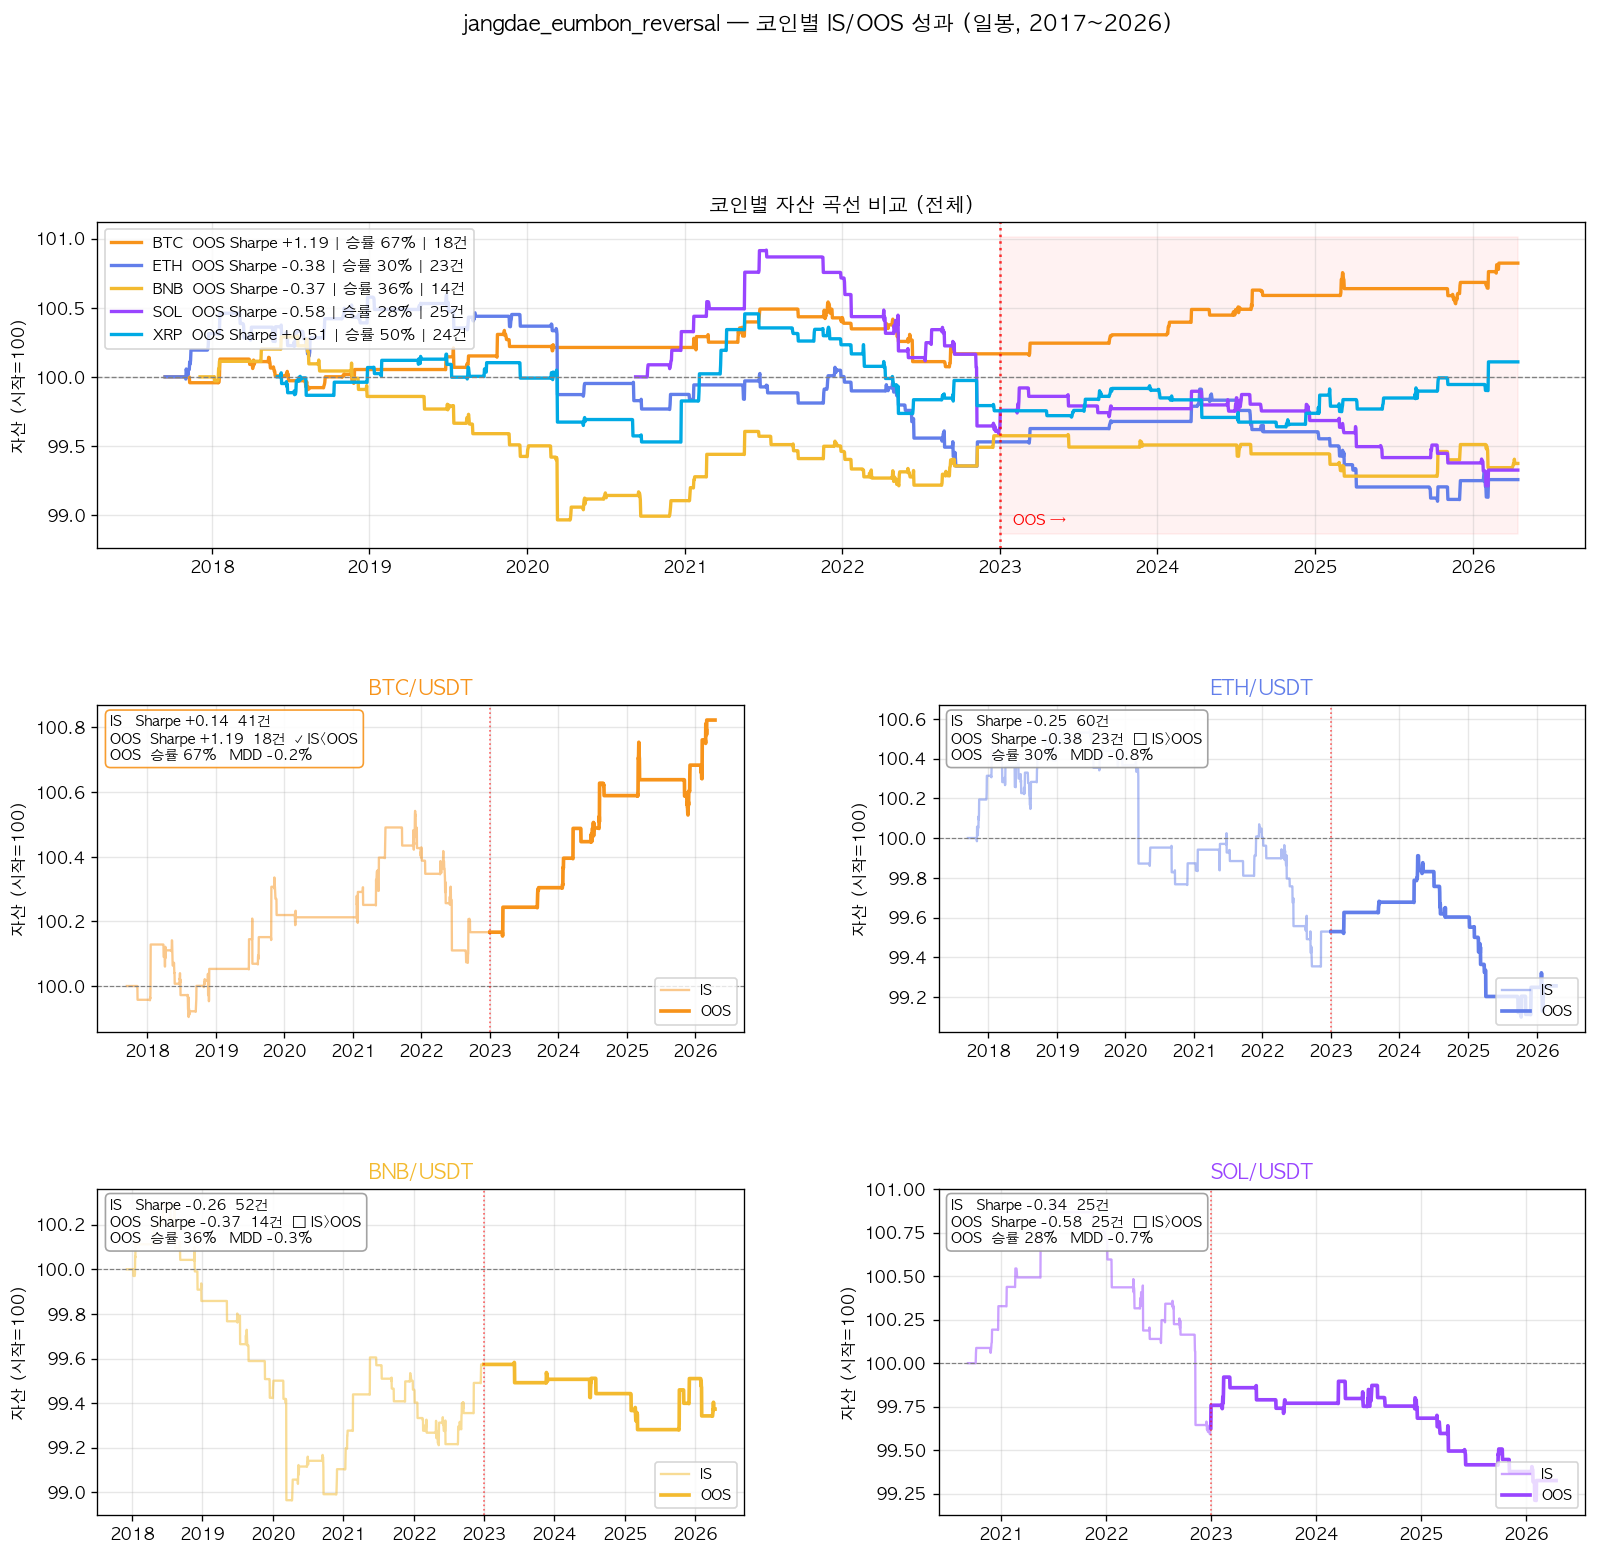

   코인 |  IS Sharpe  IS n |  OOS Sharpe  OOS n   OOS 승률  OOS MDD | 판정
---------------------------------------------------------------------------
  BTC |      +0.14    41 |       +1.19     18      67%    -0.2% | ✓
  ETH |      -0.25    60 |       -0.38     23      30%    -0.8% | ✗
  BNB |      -0.26    52 |       -0.37     14      36%    -0.3% | ✗
  SOL |      -0.34    25 |       -0.58     25      28%    -0.7% | ✗
  XRP |      -0.15    43 |       +0.51     24      50%    -0.3% | ✓


In [9]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

from strategies import get_strategy
from core.engine import run_backtest, BacktestEnv, BasicSlippage, FixedRateCommission
import matplotlib.gridspec as gridspec

env = BacktestEnv(cash=10000, slippage=BasicSlippage(bps=5), commission=FixedRateCommission(bps=10))
OOS_START = pd.Timestamp('2023-01-01', tz='UTC')

coins = [
    ('BTC', 'data/ohlcv_full_BTCUSDT_1d.parquet', '#F7931A'),
    ('ETH', 'data/ohlcv_full_ETHUSDT_1d.parquet', '#627EEA'),
    ('BNB', 'data/ohlcv_full_BNBUSDT_1d.parquet', '#F3BA2F'),
    ('SOL', 'data/ohlcv_full_SOLUSDT_1d.parquet', '#9945FF'),
    ('XRP', 'data/ohlcv_full_XRPUSDT_1d.parquet', '#00AAE4'),
]

results = {}
for name, path, color in coins:
    df_c = pd.read_parquet(path)
    dp   = get_strategy('jangdae_eumbon_reversal').prepare(df_c)
    is_s  = get_strategy('jangdae_eumbon_reversal')
    _, is_r  = run_backtest(dp[dp.index < OOS_START], is_s, env)
    oos_s = get_strategy('jangdae_eumbon_reversal')
    _, oos_r = run_backtest(dp[dp.index >= OOS_START], oos_s, env)
    full_s = get_strategy('jangdae_eumbon_reversal')
    eq_full, _ = run_backtest(dp, full_s, env)
    results[name] = {'equity': eq_full, 'color': color, 'is': is_r.metrics, 'oos': oos_r.metrics}

# ── 그래프 ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.3)

# 상단: 전체 비교
ax_main = fig.add_subplot(gs[0, :])
for name, r in results.items():
    norm = r['equity'] / r['equity'].iloc[0] * 100
    m    = r['oos']
    ax_main.plot(norm.index, norm.values, color=r['color'], linewidth=2,
        label=f"{name}  OOS Sharpe {m['sharpe']:+.2f} | 승률 {m['win_rate']*100:.0f}% | {m['total_roundtrips']}건")
ax_main.axhline(100, color='gray', linewidth=0.8, linestyle='--')
ax_main.axvline(OOS_START, color='red', linewidth=1.5, linestyle=':', alpha=0.8)
ymin, ymax = ax_main.get_ylim()
ax_main.fill_betweenx([ymin, ymax], OOS_START, norm.index[-1], alpha=0.05, color='red')
ax_main.text(OOS_START + pd.Timedelta(days=30), ymin + (ymax-ymin)*0.03, 'OOS →', color='red', fontsize=9)
ax_main.set_title('코인별 자산 곡선 비교 (전체)', fontsize=12, fontweight='bold')
ax_main.set_ylabel('자산 (시작=100)')
ax_main.legend(fontsize=9, loc='upper left')
ax_main.grid(alpha=0.3)

# 하단: 코인별 개별 (4개)
for idx, (name, r) in enumerate(list(results.items())[:4]):
    row, col = divmod(idx, 2)
    ax   = fig.add_subplot(gs[row + 1, col])
    norm = r['equity'] / r['equity'].iloc[0] * 100
    ax.plot(norm[norm.index < OOS_START].index,  norm[norm.index < OOS_START].values,
            color=r['color'], linewidth=1.4, alpha=0.5, label='IS')
    ax.plot(norm[norm.index >= OOS_START].index, norm[norm.index >= OOS_START].values,
            color=r['color'], linewidth=2.2, label='OOS')
    ax.axhline(100, color='gray', linewidth=0.7, linestyle='--')
    ax.axvline(OOS_START, color='red', linewidth=1, linestyle=':', alpha=0.6)
    m_is, m_oos = r['is'], r['oos']
    oos_ok = '✓ IS<OOS' if m_oos['sharpe'] > m_is['sharpe'] else '✗ IS>OOS'
    textstr = (
        f"IS   Sharpe {m_is['sharpe']:+.2f}  {m_is['total_roundtrips']}건\n"
        f"OOS  Sharpe {m_oos['sharpe']:+.2f}  {m_oos['total_roundtrips']}건  {oos_ok}\n"
        f"OOS  승률 {m_oos['win_rate']*100:.0f}%   MDD {m_oos['mdd']*100:.1f}%"
    )
    ec = r['color'] if m_oos['sharpe'] > 0 else '#999999'
    ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=8.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.9, edgecolor=ec))
    ax.set_title(f'{name}/USDT', fontsize=12, fontweight='bold', color=r['color'])
    ax.legend(fontsize=8.5, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_ylabel('자산 (시작=100)')

plt.suptitle('jangdae_eumbon_reversal — 코인별 IS/OOS 성과 (일봉, 2017~2026)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

# 수치 요약 테이블
print(f"{'코인':>5} | {'IS Sharpe':>10} {'IS n':>5} | {'OOS Sharpe':>11} {'OOS n':>6} {'OOS 승률':>8} {'OOS MDD':>8} | 판정")
print('-' * 75)
for name, r in results.items():
    mi, mo = r['is'], r['oos']
    ok = '✓' if mo['sharpe'] > 0 else '✗'
    print(f"{name:>5} | {mi['sharpe']:>+10.2f} {mi['total_roundtrips']:>5} | "
          f"{mo['sharpe']:>+11.2f} {mo['total_roundtrips']:>6} {mo['win_rate']*100:>7.0f}% {mo['mdd']*100:>7.1f}% | {ok}")
